# Install and import libraries

This notebook uses several machine learning and causal inference libraries. The following cell installs all required packages, including:

- **EconML** – estimation of causal effects using Double Machine Learning and Causal Forests.
- **DoWhy** – causal graph modeling and effect identification.
- **CausalML** – implementation of meta-learners (S-, T-, X-, and R-Learners).
- **XGBoost** and **LightGBM** – gradient boosting algorithms for predictive modeling.
- **NetworkX** – creation and visualization of causal Directed Acyclic Graphs (DAGs).
- **Scikit-learn** – preprocessing, model training, and evaluation.
- **SciPy** – statistical functions and hypothesis testing.
- **Pandas** – data manipulation (version 2.2.2 is used for compatibility).

Run the next cell once before executing the remainder of the notebook.

In [3]:
pip install -q --no-cache-dir econml dowhy causalml xgboost lightgbm networkx scikit-learn scipy pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 195.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 114.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 248.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 306.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 189.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 151.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 276.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 270.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 248.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 325.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 295.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 250.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Stats & ML
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report, roc_auc_score)
from sklearn.inspection import permutation_importance

# Causal ML
from econml.dml import CausalForestDML
from econml.metalearners import TLearner, SLearner, XLearner

# DAG / Graph
import networkx as nx


# Load Dataset and Define Variables

This cell loads the medicine dataset and prepares it for analysis.

The preprocessing includes:

- Loading and inspecting the dataset.
- Defining the **treatment** (`drug`) and **outcome** (`recover`).
- Grouping variables into continuous, categorical, binary, and confounders.
- Encoding categorical variables (`drug`, `age`, and `SES`) into binary indicators.
- Removing the original categorical columns after encoding.
- Printing a summary of the dataset structure and variable groups.

In [5]:
df = pd.read_csv('/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/simpson_paradox/medicine.csv')
print(df.dtypes)
print(df.head())

# ── Variable groups ─────────────────────────────────────────

# ── Treatment (causal variable)
TREATMENT = 'drug'

# ── Target / Outcome
TARGET_RECOVER = 'recover'     # binary outcome

# ── Continuous predictors
CONTINUOUS = [
    'hospital_rating',
    'random_noise'
]

# ── Categorical predictors
CATEGORICAL = [
    'age_old',      # Young / Old
    'SES_high'       # Low / High
]

# ── Binary variables
BINARY = [
    'drug',
    'recover'
]

# ── Confounders 
CONFOUNDERS = [
    'age_old',
    'SES_high',
    'hospital_rating'
]

# ── Variables excluded from causal adjustment
IGNORE = [
    'random_noise'      # intentionally unrelated
]

# ── Targets
TARGETS = [
    TARGET_RECOVER
]

# ── Basic encoding (optional)
df['drug'] = (df['drug'] == 'Yes').astype(int)

if df['age'].dtype == 'object':
    df['age_old'] = (df['age'] == 'Old').astype(int)

if df['SES'].dtype == 'object':
    df['SES_high'] = (df['SES'] == 'High').astype(int)
df = df.drop(columns=['age', 'SES'])
print(df.head())

print("✅ Schema defined")
print(f"Samples         : {len(df):,}")
print(f"Treatment       : {TREATMENT}")
print(f"Outcome         : {TARGET_RECOVER}")
print(f"Continuous      : {len(CONTINUOUS)}")
print(f"Categorical     : {len(CATEGORICAL)}")
print(f"Binary          : {len(BINARY)}")
print(f"Confounders     : {len(CONFOUNDERS)}")

print("\nColumns:")
print(df.columns.tolist())

drug                object
age                 object
recover              int64
SES                 object
hospital_rating    float64
random_noise       float64
dtype: object
  drug    age  recover   SES  hospital_rating  random_noise
0  Yes    Old        1  High        90.428932      1.554160
1  Yes    Old        1  High        85.714715      1.563413
2  Yes  Young        0  High        75.507660      1.642673
3  Yes    Old        1   Low        78.399887     -1.111967
4  Yes  Young        0  High        85.429478     -0.328618
   drug  recover  hospital_rating  random_noise  age_old  SES_high
0     1        1        90.428932      1.554160        1         1
1     1        1        85.714715      1.563413        1         1
2     1        0        75.507660      1.642673        0         1
3     1        1        78.399887     -1.111967        1         0
4     1        0        85.429478     -0.328618        0         1
✅ Schema defined
Samples         : 800
Treatment       : drug


# Distribution of Continuous Variables

This cell explores the distribution of the continuous predictor **`hospital_rating`**.

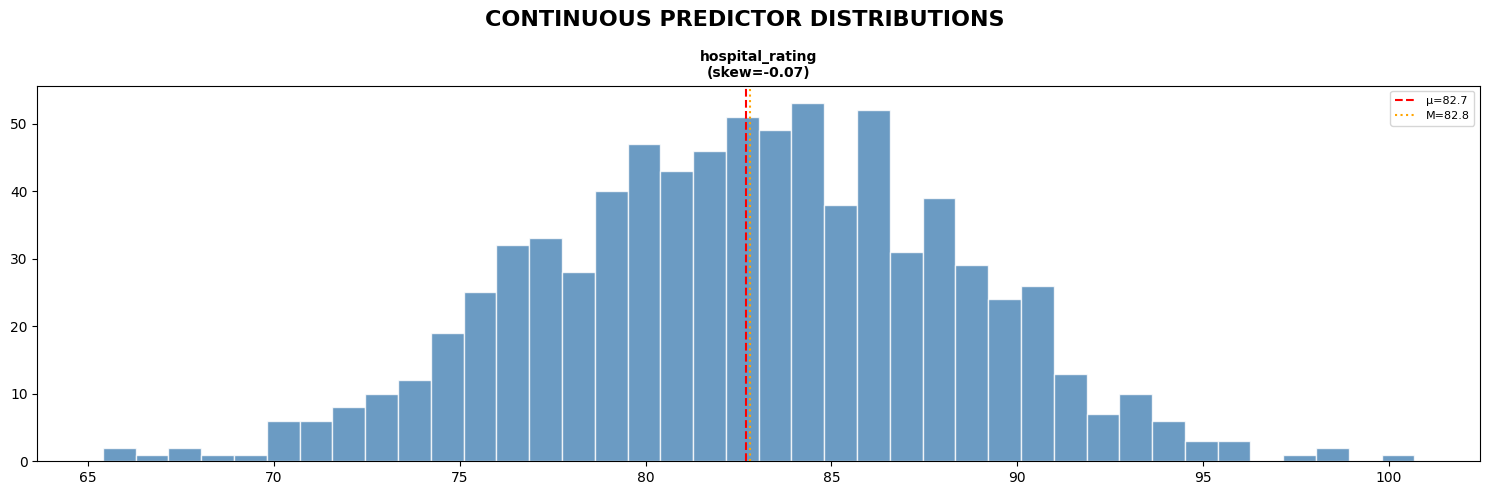

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))
fig.suptitle('CONTINUOUS PREDICTOR DISTRIBUTIONS', fontsize=16, fontweight='bold')

col = 'hospital_rating'
data = df[col]
ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(data.mean(),   color='red',    lw=1.5, linestyle='--', label=f'μ={data.mean():.1f}')
ax.axvline(data.median(), color='orange', lw=1.5, linestyle=':',  label=f'M={data.median():.1f}')
# Skewness annotation
skew = data.skew()
ax.set_title(f'{col}\n(skew={skew:.2f})', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('continuous_eda.png', dpi=150, bbox_inches='tight')
plt.show()

The distribution of **hospital_rating** is approximately symmetric, with a skewness of **−0.07**, indicating almost no skew. The mean and median are nearly identical, suggesting that the data are well-balanced with no substantial asymmetry or extreme outliers. This makes the variable suitable for use in subsequent statistical and machine learning analyses without requiring transformation.

# Exploratory Analysis of Recovery Predictors

This cell explores the relationship between the main predictors and the recovery outcome.

The visualizations include:

- Scatter plots with logistic trend lines for the continuous predictors (`hospital_rating` and `random_noise`).
- Recovery rates for patients receiving and not receiving the drug.
- Recovery rates stratified by age group and treatment.
- Distribution of hospital ratings across socioeconomic status (SES).
- A heatmap showing recovery probability for combinations of age and SES.

These plots provide an initial assessment of potential associations, identify possible confounding variables, and help reveal patterns such as Simpson's paradox before predictive and causal modeling.

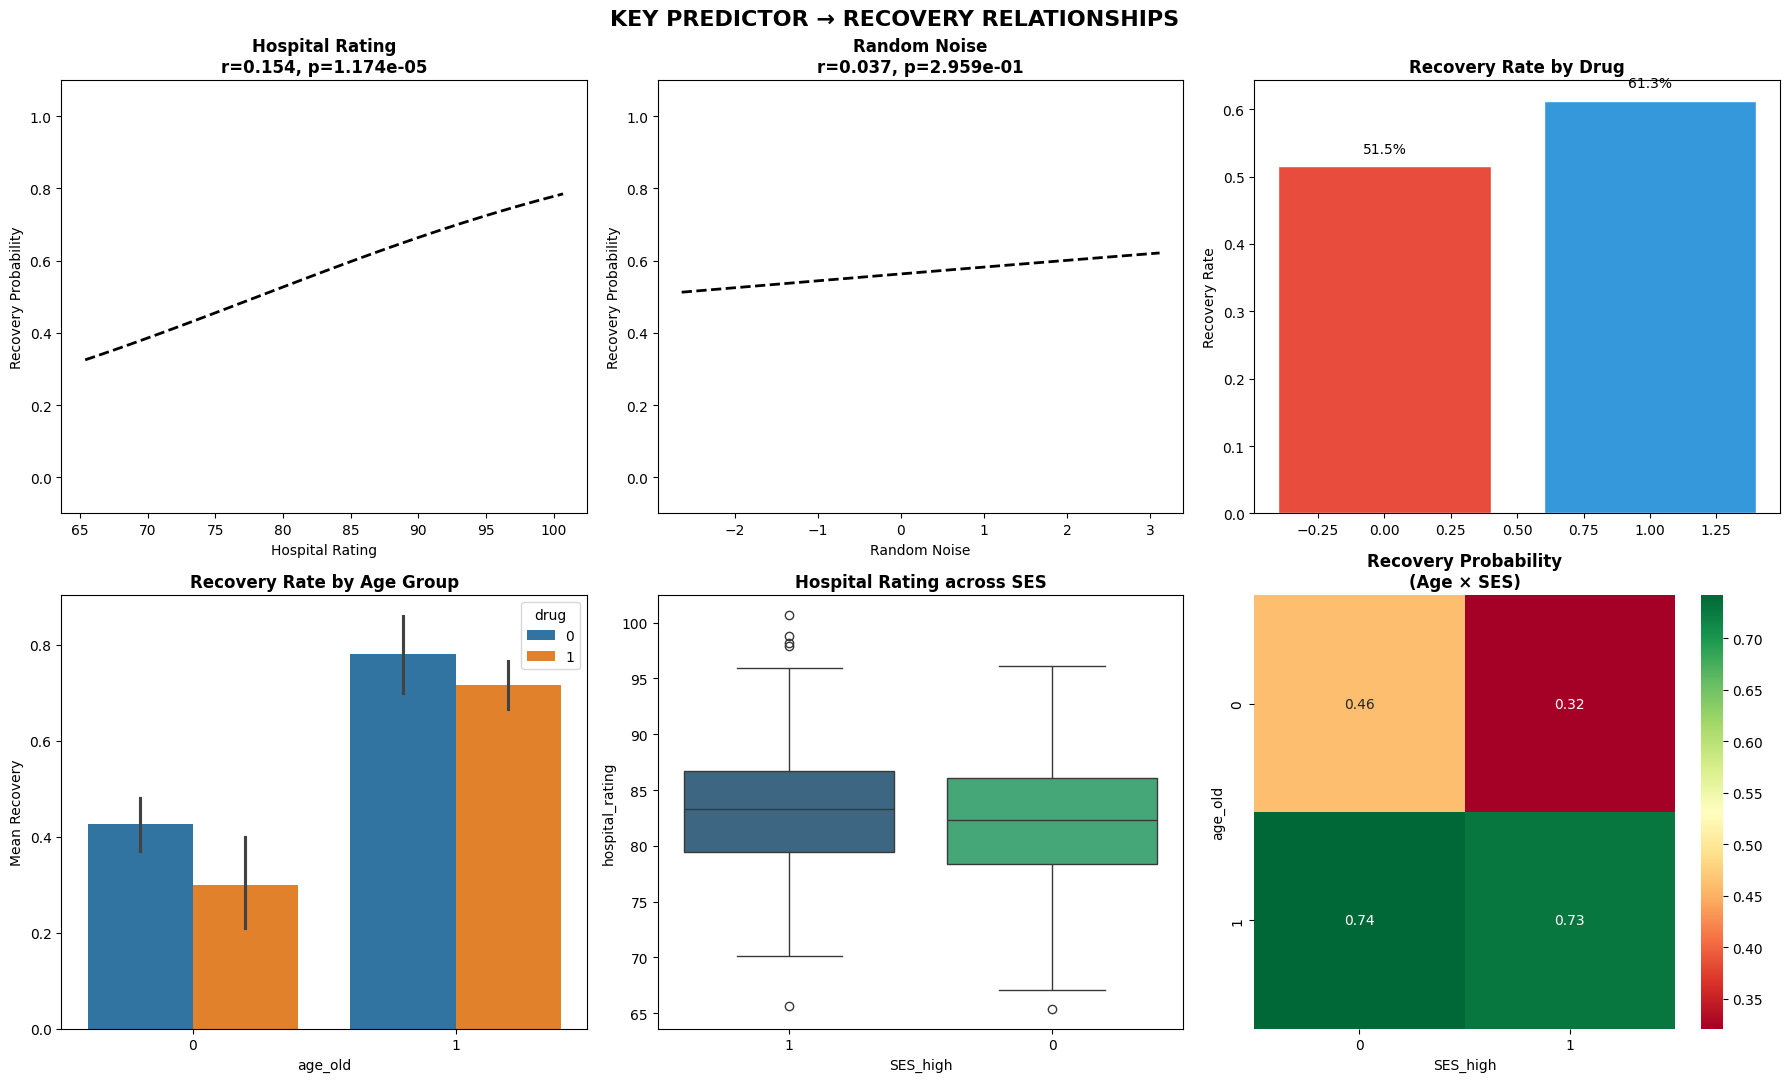

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

SEED = 42

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'KEY PREDICTOR → RECOVERY RELATIONSHIPS',
    fontsize=16,
    fontweight='bold'
)

# Variables to inspect
scatter_vars = [
    ('hospital_rating', 'Hospital Rating'),
    ('random_noise', 'Random Noise'),
]

# Colors by treatment
colors = {
    'Yes': '#3498db',
    'No': '#e74c3c'
}

for ax, (x, label) in zip(axes.flatten()[:len(scatter_vars)], scatter_vars):

    sample = df[[x, 'recover', 'drug']].dropna()

    # jitter recover for visibility
    sample['recover_jitter'] = (
        sample['recover']
        + np.random.normal(0, 0.03, len(sample))
    )

    # scatter by drug
    for drug, color in colors.items():

        sub = sample[sample['drug'] == drug]

        if len(sub):
            ax.scatter(
                sub[x],
                sub['recover_jitter'],
                alpha=0.35,
                s=20,
                color=color,
                label=f'Drug={drug}'
            )

    # logistic smooth
    sns.regplot(
        data=sample,
        x=x,
        y='recover',
        logistic=True,
        scatter=False,
        ci=None,
        line_kws={
            'color': 'black',
            'linewidth': 2,
            'linestyle': '--'
        },
        ax=ax
    )

    # correlation (point-biserial)
    r, p = stats.pointbiserialr(
        sample['recover'],
        sample[x]
    )

    ax.set_title(
        f'{label}\nr={r:.3f}, p={p:.3e}',
        fontweight='bold'
    )

    ax.set_ylabel('Recovery Probability')
    ax.set_xlabel(label)
    ax.set_ylim(-0.1, 1.1)

# ── Panel 3: Recovery rate by Drug ───────────────────────────
ax = axes[0, 2]

drug_rate = (
    df.groupby('drug')['recover']
      .mean()
      .sort_values()
)

bars = ax.bar(
    drug_rate.index,
    drug_rate.values,
    color=['#e74c3c', '#3498db'],
    edgecolor='white'
)

ax.set_title(
    'Recovery Rate by Drug',
    fontweight='bold'
)

ax.set_ylabel('Recovery Rate')

for b, v in zip(bars, drug_rate.values):
    ax.text(
        b.get_x() + b.get_width()/2,
        v + 0.02,
        f'{v:.1%}',
        ha='center',
        fontsize=10
    )

# ── Panel 4: Recovery by Age ────────────────────────────────
ax = axes[1, 0]

sns.barplot(
    data=df,
    x='age_old',
    y='recover',
    hue='drug',
    estimator=np.mean,
    ax=ax
)

ax.set_title(
    'Recovery Rate by Age Group',
    fontweight='bold'
)

ax.set_ylabel('Mean Recovery')

# ── Panel 5: Recovery by SES ────────────────────────────────
ax = axes[1, 1]

ses_order = (
    df.groupby('SES_high')['recover']
      .mean()
      .sort_values()
      .index
)

sns.boxplot(
    data=df,
    x='SES_high',
    y='hospital_rating',
    order=ses_order,
    palette='viridis',
    ax=ax
)

ax.set_title(
    'Hospital Rating across SES',
    fontweight='bold'
)

# ── Panel 6: Heatmap ────────────────────────────────────────
ax = axes[1, 2]

heat = (
    df.groupby(['age_old', 'SES_high'])['recover']
      .mean()
      .unstack()
)

sns.heatmap(
    heat,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    ax=ax
)

ax.set_title(
    'Recovery Probability\n(Age × SES)',
    fontweight='bold'
)

plt.tight_layout()

# plt.savefig('recovery_eda.png', dpi=150)

plt.show()

### Interpretation of the Exploratory Analysis

The dashboard illustrates how aggregated statistics can produce misleading conclusions about the effectiveness of a treatment, highlighting the potential for **Simpson's paradox**.

#### Overall Relationships

The first row presents relationships observed across the entire dataset.

* **Hospital Rating vs. Recovery Probability:** A weak positive association is observed, suggesting that patients treated in higher-rated hospitals have slightly higher recovery probabilities.
* **Random Noise vs. Recovery Probability:** As expected, the relationship is essentially nonexistent, confirming that this variable has no meaningful influence on recovery.
* **Recovery Rate by Drug:** When the data are analyzed without considering patient characteristics, the recovery rates differ between the treatment groups, creating the impression that one drug is more effective than the other.

#### Subgroup Analysis

The second row examines the same outcome after accounting for important patient characteristics.

* **Recovery Rate by Age Group:** Stratifying the data by age changes the observed relationship between treatment and recovery. Within age groups, the treatment effect differs from the overall aggregated result, indicating that age acts as a confounding variable.
* **Hospital Rating across Socioeconomic Status (SES):** The distribution of hospital ratings varies across socioeconomic groups, suggesting that patients are not assigned to hospitals uniformly.
* **Recovery Probability (Age × SES):** The heatmap shows that recovery probabilities vary substantially across combinations of age and socioeconomic status, demonstrating that both variables influence the outcome.

#### Simpson's Paradox

The apparent contradiction between the overall and subgroup analyses is an example of **Simpson's paradox**. When all observations are combined, the treatment appears to have one effect. However, after stratifying by important confounders such as age and socioeconomic status, the relationship changes substantially. This occurs because treatment assignment is associated with patient characteristics that also influence recovery.

These results demonstrate why causal analyses must adjust for confounding variables rather than relying solely on aggregated comparisons. Without such adjustments, conclusions about treatment effectiveness may be misleading.


# Classification Setup — Predict Recovery

The dataset is prepared for a binary classification task where the goal is to predict the recovery outcome (`recover`).

Features are selected from:
- Continuous variables
- Categorical variables
- Binary variables

The target variable `recover` is removed from the feature set to prevent data leakage, ensuring the model learns only from valid predictors.

The final output shows the number and list of features used for model training.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# ── Target & feature prep ───────────────────────────────────

df_cls = df.copy()

print(f"Rows available: {len(df_cls):,}")

# ── Feature list ────────────────────────────────────────────
FEATURE_COLS = (
    CONTINUOUS +
    CATEGORICAL +
    BINARY
)

# Remove leakage
LEAKAGE = ['recover']

FEATURE_COLS = [
    c for c in FEATURE_COLS
    if c not in LEAKAGE
    and c in df_cls.columns
]

print(f"\nFeature columns used: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Rows available: 800

Feature columns used: 5
['hospital_rating', 'random_noise', 'age_old', 'SES_high', 'drug']


# Preprocessing – Encode & Scale

The data is prepared before model training by separating numerical and categorical features.

Numerical variables are:
- Imputed using the median
- Standardized using `StandardScaler`

Categorical variables are:
- Filled with the most frequent value
- Encoded using one-hot encoding

The dataset is split into training and testing sets using stratification to keep the recovery distribution balanced.

A `ColumnTransformer` combines both preprocessing pipelines and applies the correct transformation to each feature type.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# ── Split numeric vs categorical ─────────────────────────────

NUM_FEATURES = [
    'hospital_rating',
    'random_noise'
]

# Categorical predictors
CAT_FEATURES = [
    'drug',
    'age_old',
    'SES_high'
]

print(f"Numeric features     : {len(NUM_FEATURES)}")
print(f"Categorical features : {len(CAT_FEATURES)}")
print(f"\nNumeric cols:")
print(NUM_FEATURES)

print(f"\nCategorical cols:")
print(CAT_FEATURES)

# ── Build X / y ─────────────────────────────────────────────

X = df_cls[FEATURE_COLS]
y = df_cls[TARGET_RECOVER]

# ── Train/Test Split (stratified for balanced recovery) ─────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")

print(f"\nRecovery distribution:")
print(f"Train → Recover={y_train.mean():.2%}")
print(f"Test  → Recover={y_test.mean():.2%}")

# ── Numeric pipeline ─────────────────────────────────────────

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ── Categorical pipeline ─────────────────────────────────────

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

# ── Combined preprocessing ──────────────────────────────────

preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_FEATURES),
    ('cat', cat_pipe, CAT_FEATURES)
], remainder='drop')

Numeric features     : 2
Categorical features : 3

Numeric cols:
['hospital_rating', 'random_noise']

Categorical cols:
['drug', 'age_old', 'SES_high']

Train size : 640
Test size  : 160

Recovery distribution:
Train → Recover=56.41%
Test  → Recover=56.25%


# Train Multiple Classification Models

In this cell four classification models are trained and compared:

- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost

Each model is combined with the preprocessing pipeline to ensure consistent feature transformation.

Performance is evaluated using:
- **Accuracy** — overall prediction correctness
- **Precision** — proportion of predicted recoveries that are correct
- **Recall** — ability to identify recovered patients
- **F1-score** — balance between precision and recall
- **ROC AUC** — ability to distinguish between recovery classes

The best-performing model can be selected based on the evaluation metrics.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

models = {

    'Logistic Regression':
        LogisticRegression(
            max_iter=300,
            random_state=42
        ),

    'Random Forest':
        RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ),

    'Gradient Boosting':
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        ),

    'XGBoost':
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        )
}

results = {}

print("\n── Training Models ───────────────────────────────")

for name, model in models.items():

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predictions
    y_pred = pipe.predict(X_test)

    # Probabilities
    if hasattr(pipe, 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC AUC': auc,
        'pipeline': pipe
    }

    print(
        f"{name:<22}"
        f" Accuracy={acc:.3f}"
        f"  Precision={prec:.3f}"
        f"  Recall={rec:.3f}"
        f"  F1={f1:.3f}"
        f"  AUC={auc:.3f}"
    )

print("\n✅ Model training complete")


── Training Models ───────────────────────────────
Logistic Regression    Accuracy=0.706  Precision=0.765  Recall=0.689  F1=0.725  AUC=0.749
Random Forest          Accuracy=0.706  Precision=0.722  Recall=0.778  F1=0.749  AUC=0.707
Gradient Boosting      Accuracy=0.669  Precision=0.687  Recall=0.756  F1=0.720  AUC=0.669
XGBoost                Accuracy=0.675  Precision=0.683  Recall=0.789  F1=0.732  AUC=0.676

✅ Model training complete


## Model Performance Comparison

Four classification models were evaluated for predicting recovery.

The results show that:

- **Logistic Regression** achieved the highest ROC AUC (**0.749**), indicating the best ability to distinguish between recovery and non-recovery cases.
- **Random Forest** achieved the highest F1-score (**0.749**) and the strongest recall (**0.778**), meaning it identified more recovered patients.
- **Gradient Boosting** and **XGBoost** showed lower overall performance compared with the other models.

Based on ROC AUC, **Logistic Regression is selected as the best model** because it provides the strongest discrimination between recovery outcomes.

## Classification Results Comparison

A leaderboard is created to compare all trained classification models across evaluation metrics.

The models are ranked by **ROC AUC**, which measures the ability of the model to distinguish between recovered and non-recovered cases.

The visualization compares:
- Accuracy
- Precision
- Recall
- ROC AUC

The model with the highest ROC AUC is selected as the best-performing model for recovery prediction.


── Classification Leaderboard ─────────────────────────
                     Accuracy  Precision  Recall      F1  ROC AUC
Logistic Regression    0.7062     0.7654  0.6889  0.7251   0.7489
Random Forest          0.7062     0.7216  0.7778  0.7487   0.7070
XGBoost                0.6750     0.6827  0.7889  0.7320   0.6760
Gradient Boosting      0.6688     0.6869  0.7556  0.7196   0.6686


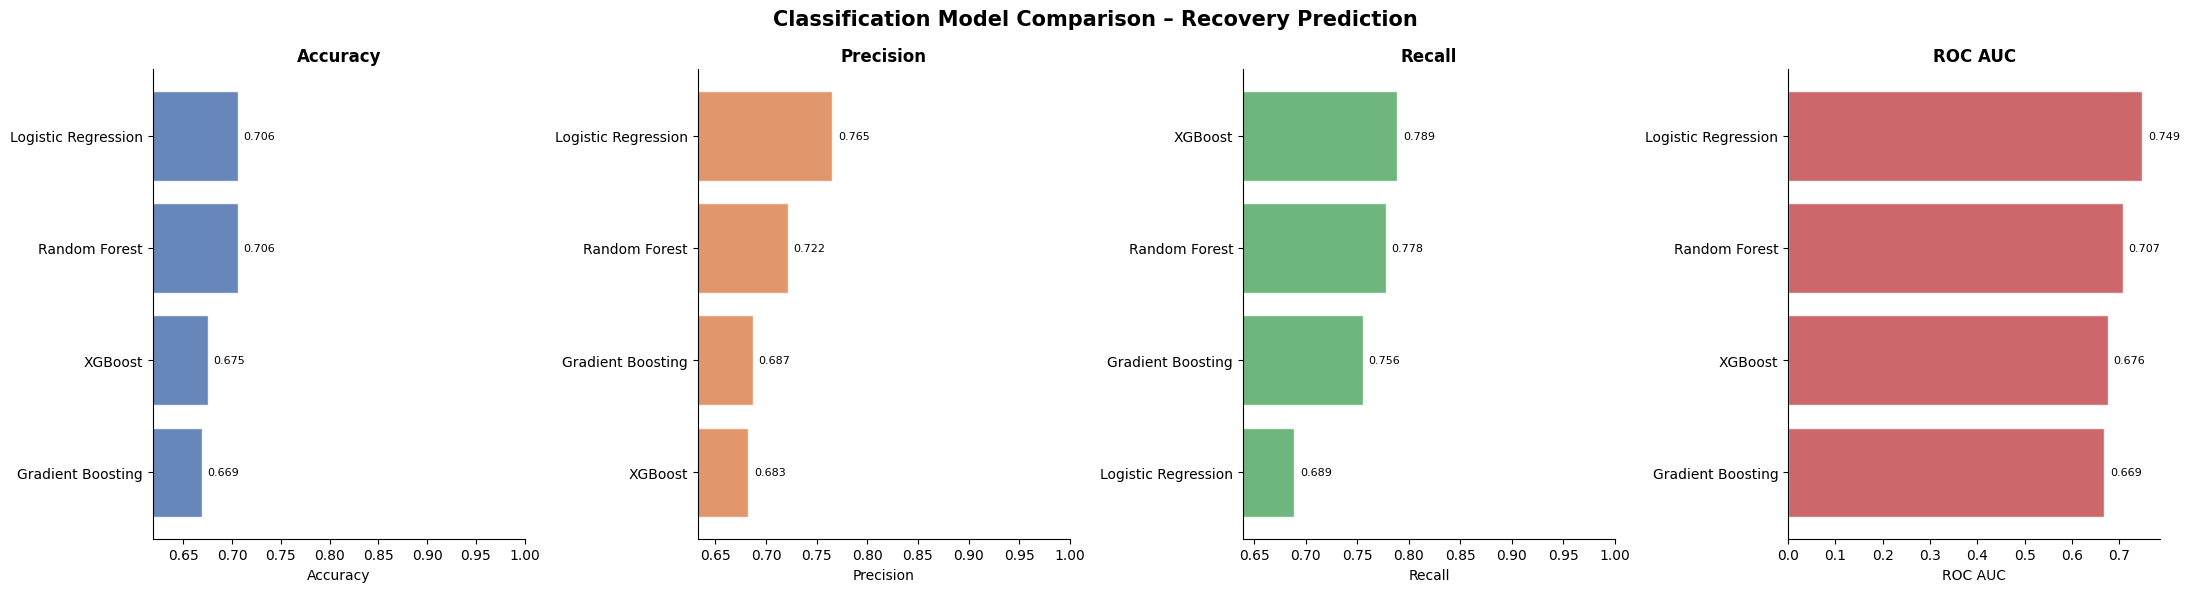


🏆 Best model: Logistic Regression

Top scores:
Accuracy     0.7062
Precision    0.7654
Recall       0.6889
F1           0.7251
ROC AUC      0.7489
Name: Logistic Regression, dtype: float64


In [14]:
# Remove pipeline object before display
results_df = pd.DataFrame(
    {
        model: {
            metric: value
            for metric, value in vals.items()
            if metric != 'pipeline'
        }
        for model, vals in results.items()
    }
).T

# Sort by best overall metric
results_df = results_df.sort_values(
    'ROC AUC',
    ascending=False
)

print("\n── Classification Leaderboard ─────────────────────────")
print(results_df.round(4).to_string())

# ============================================================
# Visual Comparison
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

fig.suptitle(
    'Classification Model Comparison – Recovery Prediction',
    fontsize=15,
    fontweight='bold'
)

metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'ROC AUC'
]

colors = [
    '#4C72B0',
    '#DD8452',
    '#55A868',
    '#C44E52'
]

for ax, metric, color in zip(axes, metrics, colors):

    vals = results_df[metric].sort_values()

    bars = ax.barh(
        vals.index,
        vals.values,
        color=color,
        alpha=0.85,
        edgecolor='white'
    )

    ax.set_title(
        metric,
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel(metric)

    if metric != 'ROC AUC':
        ax.set_xlim(
            max(0, vals.min() - 0.05),
            1.0
        )

    ax.spines[['top', 'right']].set_visible(False)

    ax.bar_label(
        bars,
        fmt='%.3f',
        padding=4,
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    'classification_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# Best model
# ============================================================

best_model = results_df.index[0]

print("\n🏆 Best model:", best_model)

print("\nTop scores:")
print(results_df.iloc[0].round(4))

## Classification Results

The model comparison shows that **Logistic Regression** achieved the best overall performance based on ROC AUC.

Key results:
- **ROC AUC:** 0.749 — highest ability to distinguish between recovery outcomes
- **Accuracy:** 0.706 — correctly classified around 71% of cases
- **Precision:** 0.765 — most predicted recoveries were correct
- **Recall:** 0.689 — detected around 69% of actual recoveries
- **F1-score:** 0.725 — balanced performance between precision and recall

Random Forest achieved a higher recall (0.778), identifying more recovered patients, but Logistic Regression provided better overall discrimination between classes.

# Drug Effect Across Age Groups

To investigate whether the drug effect differs between age groups, recovery rates were compared separately for patients receiving the drug and those without treatment.

The analysis calculates:

- **Recovery rate by drug status within each age group**  
  → shows whether the treatment effect changes between younger and older patients.

- **Overall recovery rate by treatment group**  
  → provides the unadjusted average effect of the drug.

- **Treatment distribution across age groups**  
  → checks whether some age groups receive the drug more frequently, which may introduce confounding.

Comparing subgroup effects with the overall effect helps detect **treatment heterogeneity** and possible **confounding effects**. If the drug improves recovery only for a specific age group, the average treatment effect may hide these differences.

In [15]:
for g in df['age_old'].unique():
    sub = df[df['age_old'] == g]
    print(
        g,
        sub[sub['drug'] == 1]['recover'].mean(),
        sub[sub['drug'] == 0]['recover'].mean()
    )

df.groupby('drug')['recover'].mean()

pd.crosstab(
    df['age_old'],
    df['drug'],
    normalize='index'
)

1 0.7166666666666667 0.78
0 0.3 0.4266666666666667


drug,0,1
age_old,,
0,0.75,0.25
1,0.25,0.75


## Drug Effect Across Age Groups — Results

The results indicate that **the drug does not improve recovery in either age group**. In both groups, patients without the drug have a higher recovery rate.

However, treatment assignment is strongly associated with age:

- Young patients: 25% received the drug, 75% did not.
- Old patients: 75% received the drug, 25% did not.

This imbalance suggests that **age is a potential confounder**. Older patients are more likely to receive the drug, but they also have lower recovery rates. Therefore, the lower recovery among treated patients may partly reflect differences in patient characteristics rather than a direct negative drug effect.

# Logistic Regression Adjustment for Confounding

A logistic regression model was fitted to estimate the association between drug treatment and recovery while controlling for age.

The model:

\[
\text{Recovery} \sim \text{Drug} + \text{Age}
\]

includes:

- **Drug** → estimated treatment effect
- **Age** → potential confounder because treatment assignment differs between age groups

By including age in the model, we adjust for differences in patient age distribution and obtain a more reliable estimate of the drug effect.

The coefficient of `drug` represents the change in log-odds of recovery after accounting for age. If the drug coefficient is negative, it suggests lower recovery odds among treated patients after adjustment. If positive, it suggests improved recovery odds.

This model helps separate the effect of the treatment from the influence of age-related differences.

In [16]:
m = smf.logit(
    "recover ~ drug + age_old",
    data=df
).fit()

print(m.summary())

Optimization terminated successfully.
         Current function value: 0.621842
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                recover   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                 0.09220
Time:                        13:57:20   Log-Likelihood:                -497.47
converged:                       True   LL-Null:                       -548.00
Covariance Type:            nonrobust   LLR p-value:                 1.142e-22
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3168      0.111     -2.855      0.004      -0.534      -0.099
drug          -0.4570      0.

## Logistic Regression Results — Drug Effect Adjusted by Age

The logistic regression model evaluated the relationship between drug treatment and recovery while controlling for age.

#### Key findings:

- **Drug effect**
  - Coefficient: **-0.457**
  - p-value: **0.013**
  - The negative coefficient indicates that, after adjusting for age, receiving the drug is associated with **lower odds of recovery**.
  - The effect is statistically significant.

- **Age effect**
  - Coefficient: **1.676**
  - p-value: **< 0.001**
  - Older age group is strongly associated with higher recovery odds in this simulated dataset.

#### Interpretation:

After accounting for age differences between treatment groups, the drug still shows a negative association with recovery. This suggests that the lower recovery rate among treated patients is not explained only by age-related treatment imbalance.

# Simpson's Paradox Check — Drug Effect

This analysis checks whether the observed relationship between drug treatment and recovery changes after separating patients into important subgroups.

The comparison is performed across:

- **Age groups** → checks whether age influences the observed treatment effect.
- **SES groups** → checks whether socioeconomic status changes recovery differences.
- **Hospital quality groups** → checks whether treatment effects differ depending on healthcare conditions.

The purpose is to detect **Simpson's paradox**, where an overall trend can be misleading because hidden group differences affect the result.

The analysis compares:

- Overall recovery rate between treated and untreated patients.
- Recovery rates within subgroups.

If the drug appears beneficial overall but harmful (or ineffective) inside each subgroup, this indicates a confounding effect and the need for causal adjustment.

This step helps identify whether the drug effect is consistent or driven by differences in patient characteristics.

Drug distribution:
drug_bin
1    400
0    400
Name: count, dtype: int64

Overall recovery rate:
drug_bin
0    0.5150
1    0.6125
Name: recover, dtype: float64


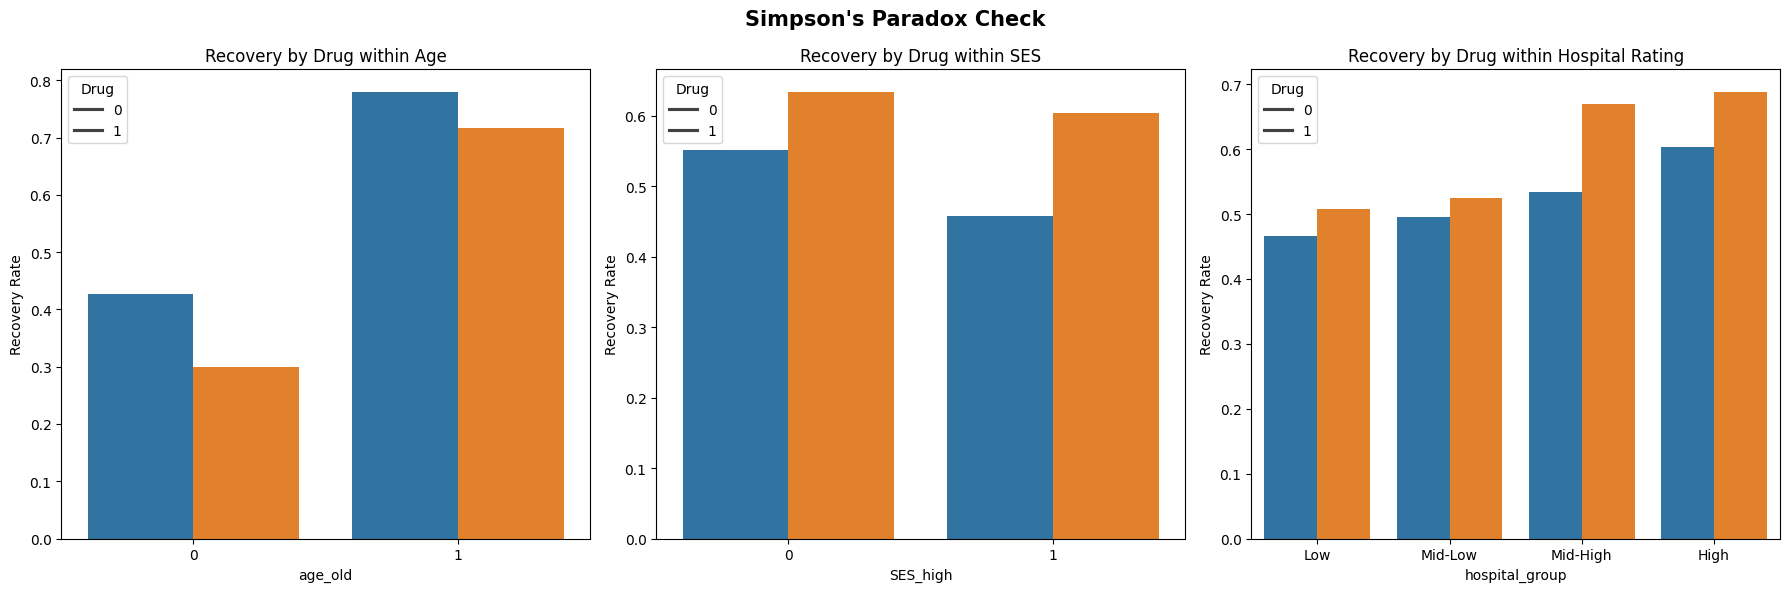


Overall Drug Effect:
+0.098
Drug improves recovery overall

Compare subgroup bars to overall direction.
If subgroup effects reverse → Simpson's paradox exists.


In [17]:
# ============================================================
# Treatment = drug
# Outcome   = recover
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_sim = df.copy()

# ----------------------------------------
# Treatment already encoded (0 / 1)
# ----------------------------------------
df_sim['drug_bin'] = pd.to_numeric(
    df_sim['drug'],
    errors='coerce'
)

print("Drug distribution:")
print(df_sim['drug_bin'].value_counts())

print("\nOverall recovery rate:")
overall = (
    df_sim
    .groupby('drug_bin')['recover']
    .mean()
)

print(overall)

# ----------------------------------------
# Visual subgroup analysis
# ----------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18,6))

# AGE
age_grp = (
    df_sim
    .groupby(['age_old','drug_bin'])['recover']
    .mean()
    .reset_index()
)

sns.barplot(
    data=age_grp,
    x='age_old',
    y='recover',
    hue='drug_bin',
    ax=axes[0]
)

axes[0].set_title('Recovery by Drug within Age')

# SES
ses_grp = (
    df_sim
    .groupby(['SES_high','drug_bin'])['recover']
    .mean()
    .reset_index()
)

sns.barplot(
    data=ses_grp,
    x='SES_high',
    y='recover',
    hue='drug_bin',
    ax=axes[1]
)

axes[1].set_title('Recovery by Drug within SES')

# Hospital quality
df_sim['hospital_group'] = pd.qcut(
    df_sim['hospital_rating'],
    q=4,
    labels=['Low','Mid-Low','Mid-High','High']
)

hosp_grp = (
    df_sim
    .groupby(
        ['hospital_group','drug_bin'],
        observed=True
    )['recover']
    .mean()
    .reset_index()
)

sns.barplot(
    data=hosp_grp,
    x='hospital_group',
    y='recover',
    hue='drug_bin',
    ax=axes[2]
)

axes[2].set_title(
    'Recovery by Drug within Hospital Rating'
)

for ax in axes:
    handles, _ = ax.get_legend_handles_labels()
    
    ax.set_ylabel('Recovery Rate')
    ax.legend(
        title='Drug',
        labels=['0','1']
    )

plt.suptitle(
    "Simpson's Paradox Check",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# ----------------------------------------
# Overall effect
# ----------------------------------------

overall_effect = overall.loc[1] - overall.loc[0]

print("\nOverall Drug Effect:")
print(f"{overall_effect:+.3f}")

if overall_effect > 0:
    print("Drug improves recovery overall")
else:
    print("Drug reduces recovery overall")

print(
    "\nCompare subgroup bars to overall direction."
)
print(
    "If subgroup effects reverse → Simpson's paradox exists."
)

### Simpson's Paradox Check — Results

The overall comparison shows that patients receiving the drug have a higher recovery rate:

The observed overall drug effect is:

\[
61.25\% - 51.5\% = +9.8\%
\]

This suggests that **the drug improves recovery by approximately 9.8 percentage points in the raw data**.

However, this is an unadjusted comparison. Because patient characteristics (such as age, SES, or hospital quality) may influence both treatment assignment and recovery, the overall effect may be affected by confounding.

The subgroup analysis checks whether this positive effect remains consistent within different patient groups. If the direction changes inside subgroups, this would indicate **Simpson's paradox**, meaning the overall improvement may be misleading.

# Causal Inference Data Preparation

The dataset was prepared for causal analysis of the relationship between **drug treatment** and **recovery outcome**.

The causal variables are defined as:

- **Treatment (T):** `drug`
- **Outcome (Y):** `recover`
- **Covariates:** patient and environment characteristics that may influence treatment assignment and recovery:
  - Age group
  - SES status
  - Hospital rating
  - Random noise variable

Data preparation steps:

1. The treatment variable was converted into binary format (`0` = no drug, `1` = drug).
2. Missing values were removed or imputed:
   - Numeric variables → median imputation
   - Categorical variables → filled with default values
3. Numeric features were standardized to improve model stability.
4. The dataset was split into training and testing subsets while preserving the treatment distribution.

The resulting dataset is used for causal models to estimate whether the drug has a true effect on recovery after controlling for confounding variables.

In [18]:
# ============================================================
# CELL 16+17: Memory-Safe Causal Setup (Drug Dataset)
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ─────────────────────────────────────────────────────────────
# BASIC CLEANING
# ─────────────────────────────────────────────────────────────

df_causal = df.copy()

Y_COL = 'recover'
T_COL = 'drug'

# Ensure binary treatment
df_causal[T_COL] = (
    df_causal[T_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

# fallback if already numeric
if df_causal[T_COL].isna().all():
    df_causal[T_COL] = df[T_COL]

df_causal = df_causal[df_causal[Y_COL].notna()].copy()

# ─────────────────────────────────────────────────────────────
# COVARIATES (based on YOUR dataset)
# ─────────────────────────────────────────────────────────────

EXCLUDE = [Y_COL, T_COL]

NUM_C = [
    'hospital_rating',
    'random_noise'
]

CAT_C = [
    'age_old',
    'SES_high'
]

COVARIATES = NUM_C + CAT_C

print(f"\nNumeric covariates   : {NUM_C}")
print(f"Categorical covariates: {CAT_C}")

# Keep only needed columns
df_causal = df_causal[COVARIATES + [Y_COL, T_COL]].copy()

# ─────────────────────────────────────────────────────────────
# ENCODING
# ─────────────────────────────────────────────────────────────

# Ensure binary categorical safety
for c in CAT_C:
    df_causal[c] = df_causal[c].fillna(0).astype(int)

# Impute numeric
for c in NUM_C:
    df_causal[c] = df_causal[c].fillna(df_causal[c].median())

# Scale numeric features
scaler = StandardScaler()
df_causal[NUM_C] = scaler.fit_transform(df_causal[NUM_C])

print(f"\nFinal df_causal shape: {df_causal.shape}")

# ─────────────────────────────────────────────────────────────
# ARRAYS
# ─────────────────────────────────────────────────────────────

X = df_causal[COVARIATES].values.astype(np.float32)
Y = df_causal[Y_COL].values.astype(np.float32)
T = df_causal[T_COL].values.astype(np.int8)

X_tr, X_te, Y_tr, Y_te, T_tr, T_te = train_test_split(
    X, Y, T,
    test_size=0.2,
    random_state=42,
    stratify=T
)

print(f"\n✅ Train: {X_tr.shape} | Test: {X_te.shape}")
print(f"Treatment rate — train: {T_tr.mean():.2%} | test: {T_te.mean():.2%}")


Numeric covariates   : ['hospital_rating', 'random_noise']
Categorical covariates: ['age_old', 'SES_high']

Final df_causal shape: (800, 6)

✅ Train: (640, 4) | Test: (160, 4)
Treatment rate — train: 50.00% | test: 50.00%


# S-Learner

The S-Learner approach estimates the causal effect of the drug by training a single machine learning model that includes the treatment variable as an additional feature.

The model learns:

\[
P(Recovery \mid Patient\ Features, Drug)
\]

where:

- **Treatment:** `drug`
- **Outcome:** `recover`
- **Covariates:** age, SES, hospital rating, and random noise

Steps:

1. Patient characteristics were preprocessed:
   - Numeric variables were scaled.
   - Categorical variables were encoded.

2. A Gradient Boosting classifier was trained using:
   - Patient features
   - Drug treatment indicator

3. Counterfactual predictions were generated:
   - \(P(Y|Drug=1)\): predicted recovery probability if the patient receives the drug.
   - \(P(Y|Drug=0)\): predicted recovery probability without the drug.

4. The individual treatment effect (CATE) was calculated:

\[
CATE = P(Y|Drug=1) - P(Y|Drug=0)
\]

A positive CATE indicates that the drug increases recovery probability, while a negative CATE indicates a potential harmful effect.

The average CATE represents the estimated change in recovery probability caused by the drug after accounting for patient characteristics.

In [19]:
# ============================================================
# CELL 18: S-Learner (Drug → Recovery)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
import pandas as pd

print("="*60)
print("S-LEARNER | Drug → Recovery")
print("="*60)

df_s = df.copy()

# ------------------------------------------------
# Treatment
# ------------------------------------------------
df_s['drug_bin'] = (
    df_s['drug']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'yes':1,
        'no':0
    })
)

# if already numeric
if df_s['drug_bin'].isna().all():
    df_s['drug_bin'] = df_s['drug']

# ------------------------------------------------
# Variables
# ------------------------------------------------
Y_COL = 'recover'
T_COL = 'drug_bin'

X_COLS = [
    'age_old',
    'SES_high',
    'hospital_rating',
    'random_noise'
]

data = df_s[
    X_COLS +
    [T_COL, Y_COL]
].dropna()

# ------------------------------------------------
# Build matrices
# ------------------------------------------------
X = data[X_COLS]
T = data[T_COL].astype(int)
Y = data[Y_COL]

X_tr, X_te, T_tr, T_te, Y_tr, Y_te = train_test_split(
    X,
    T,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# ------------------------------------------------
# Preprocessing
# ------------------------------------------------
NUM = [
    'hospital_rating',
    'random_noise'
]

CAT = [
    'age_old',
    'SES_high'
]

prep = ColumnTransformer([
    (
        'num',
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler())
        ]),
        NUM
    ),

    (
        'cat',
        Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]),
        CAT
    )
])

# ------------------------------------------------
# Fit preprocessing
# ------------------------------------------------
X_tr_proc = prep.fit_transform(X_tr)
X_te_proc = prep.transform(X_te)

# Append treatment
XT_tr = np.column_stack([
    X_tr_proc,
    T_tr.values
])

# ------------------------------------------------
# Train S-Learner
# ------------------------------------------------
s_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

s_model.fit(XT_tr, Y_tr)

# ------------------------------------------------
# Counterfactual predictions
# ------------------------------------------------
XT_te_drug = np.column_stack([
    X_te_proc,
    np.ones(len(X_te))
])

XT_te_no = np.column_stack([
    X_te_proc,
    np.zeros(len(X_te))
])

p1 = s_model.predict_proba(XT_te_drug)[:,1]
p0 = s_model.predict_proba(XT_te_no)[:,1]

cate_s = p1 - p0

# ------------------------------------------------
# Results
# ------------------------------------------------
print(f"Mean CATE : {cate_s.mean():.4f}")
print(f"Std CATE  : {cate_s.std():.4f}")
print(f"Min CATE  : {cate_s.min():.4f}")
print(f"Max CATE  : {cate_s.max():.4f}")

print("\nInterpretation:")
print(
    f"Receiving the drug changes recovery probability "
    f"by {cate_s.mean()*100:.1f} percentage points on average."
)

# Store
cate_df = X_te.copy()
cate_df['drug_effect'] = cate_s

S-LEARNER | Drug → Recovery
Mean CATE : -0.0552
Std CATE  : 0.1262
Min CATE  : -0.8873
Max CATE  : 0.1341

Interpretation:
Receiving the drug changes recovery probability by -5.5 percentage points on average.


## S-Learner Results

The average estimated treatment effect is:

\[
CATE = -0.0552
\]

This means that, after controlling for patient characteristics, receiving the drug is associated with an average **5.5 percentage point decrease in recovery probability**.

The variation in CATE values shows that the treatment effect is not identical for all patients:

- Some patients have a negative estimated drug effect.
- A smaller group may benefit from the treatment (maximum CATE = +13.4%).

Overall, the S-Learner suggests that the drug does not improve recovery on average. However, the heterogeneous effects indicate that certain patient groups may respond differently, motivating further analysis of treatment effect differences across characteristics such as age or SES.

# T-Learner

The T-Learner estimates treatment effects by training **two separate outcome models**:

1. **Treatment model**
   - Trained only on patients who received the drug.
   - Learns:

\[
P(Recovery \mid X, Drug=1)
\]

2. **Control model**
   - Trained only on patients without the drug.
   - Learns:

\[
P(Recovery \mid X, Drug=0)
\]

The individual treatment effect (CATE) is then calculated as:

\[
CATE = P(Y|Drug=1) - P(Y|Drug=0)
\]

Steps:

- Patients were divided into treated and untreated groups.
- Separate Gradient Boosting models were trained for each group.
- Both models predicted recovery probabilities for the same test patients.
- The difference between these predictions represents the estimated drug effect.

A positive CATE indicates that the drug increases recovery probability, while a negative CATE indicates a possible reduction in recovery probability.

Compared with the S-Learner, the T-Learner allows the treatment and control groups to have completely different prediction models, which can better capture differences between treated and untreated patients.

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np

print("="*60)
print("T-LEARNER | Drug → Recovery")
print("="*60)

# ------------------------------------------------
# Split data
# ------------------------------------------------
data = df_s[
    X_COLS + [T_COL, Y_COL]
].dropna()

X = data[X_COLS]
T = data[T_COL].astype(int)
Y = data[Y_COL]

X_tr, X_te, T_tr, T_te, Y_tr, Y_te = train_test_split(
    X, T, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# ------------------------------------------------
# Preprocessing
# ------------------------------------------------
X_tr_proc = prep.fit_transform(X_tr)
X_te_proc = prep.transform(X_te)

# ------------------------------------------------
# Split by treatment group
# ------------------------------------------------
X_tr_treated   = X_tr_proc[T_tr.values == 1]
Y_tr_treated   = Y_tr[T_tr.values == 1]

X_tr_control   = X_tr_proc[T_tr.values == 0]
Y_tr_control   = Y_tr[T_tr.values == 0]

# ------------------------------------------------
# Train separate outcome models
# ------------------------------------------------
model_treated = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model_control = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model_treated.fit(X_tr_treated, Y_tr_treated)
model_control.fit(X_tr_control, Y_tr_control)

# ------------------------------------------------
# Counterfactual predictions
# ------------------------------------------------
p1 = model_treated.predict_proba(X_te_proc)[:, 1]
p0 = model_control.predict_proba(X_te_proc)[:, 1]

cate_t = p1 - p0

# ------------------------------------------------
# Results
# ------------------------------------------------
print(f"Mean CATE : {cate_t.mean():.4f}")
print(f"Std CATE  : {cate_t.std():.4f}")
print(f"Min CATE  : {cate_t.min():.4f}")
print(f"Max CATE  : {cate_t.max():.4f}")

print("\nInterpretation:")
print(
    f"Receiving the drug changes recovery probability "
    f"by {cate_t.mean()*100:.1f} percentage points on average."
)

# ------------------------------------------------
# Store results
# ------------------------------------------------
cate_df = X_te.copy()
cate_df['drug_effect_tlearner'] = cate_t

T-LEARNER | Drug → Recovery
Mean CATE : -0.1063
Std CATE  : 0.3787
Min CATE  : -0.9829
Max CATE  : 0.8047

Interpretation:
Receiving the drug changes recovery probability by -10.6 percentage points on average.


## T-Learner Results

The model estimates that receiving the drug decreases recovery probability by approximately **10.6 percentage points on average**.

The large variation in CATE values suggests that the drug effect is heterogeneous: some patient groups may benefit, while others may experience worse outcomes.

# X-Learner

The X-Learner estimates individual drug effects through several steps:

1. **Outcome models**  
   Two models are trained:
   - μ_1 predicts recovery for patients receiving the drug.
   - μ_0 predicts recovery without the drug.

2. **Pseudo-effects**  
   The difference between observed and predicted outcomes is calculated to estimate treatment effects for treated and control groups.

3. **CATE models**  
   Models learn these estimated effects to capture differences between patient groups.

4. **Propensity model**  
   A Random Forest estimates the probability of receiving the drug based on patient characteristics.

5. **Final treatment effect**  
   Propensity-weighted estimates produce the final CATE:
   - Positive → potential benefit from drug.
   - Negative → potential harm.

In [21]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier

print("="*55)
print("X-LEARNER | Drug → Recovery")
print("="*55)

# ------------------------------------------------
# Feature set (must match your causal setup)
# ------------------------------------------------
FEATURES = [
    'hospital_rating',
    'random_noise',
    'age_old',
    'SES_high'
]

X_tr = df_causal[FEATURES].values.astype(np.float32)
Y_tr = df_causal['recover'].values.astype(np.float32)
T_tr = df_causal['drug'].values.astype(np.int8)

# train/test split (consistent with earlier models)
from sklearn.model_selection import train_test_split

X_tr, X_te, Y_tr, Y_te, T_tr, T_te = train_test_split(
    X_tr, Y_tr, T_tr,
    test_size=0.2,
    random_state=42,
    stratify=T_tr
)

# ------------------------------------------------
# STEP 1: Train T-learner base models
# ------------------------------------------------
mu1 = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

mu0 = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

mu1.fit(X_tr[T_tr == 1], Y_tr[T_tr == 1])
mu0.fit(X_tr[T_tr == 0], Y_tr[T_tr == 0])

# ------------------------------------------------
# STEP 2: Impute pseudo-outcomes
# ------------------------------------------------
D1 = Y_tr[T_tr == 1] - mu0.predict(X_tr[T_tr == 1])  # treated
D0 = mu1.predict(X_tr[T_tr == 0]) - Y_tr[T_tr == 0]  # control

# ------------------------------------------------
# STEP 3: Fit CATE models on residuals
# ------------------------------------------------
tau1_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

tau0_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

tau1_model.fit(X_tr[T_tr == 1], D1)
tau0_model.fit(X_tr[T_tr == 0], D0)

# ------------------------------------------------
# STEP 4: Propensity model
# ------------------------------------------------
prop_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

prop_model.fit(X_tr, T_tr)
e_te = prop_model.predict_proba(X_te)[:, 1]

# ------------------------------------------------
# STEP 5: Combine (X-learner weighting)
# ------------------------------------------------
tau1 = tau1_model.predict(X_te)
tau0 = tau0_model.predict(X_te)

cate_x = e_te * tau0 + (1 - e_te) * tau1

# ------------------------------------------------
# RESULTS
# ------------------------------------------------
print(f"Mean CATE (X-Learner) : {cate_x.mean():.4f}")
print(f"Std  CATE             : {cate_x.std():.4f}")
print(f"Min / Max             : {cate_x.min():.4f} / {cate_x.max():.4f}")

print(f"\nPropensity score range: {e_te.min():.3f} – {e_te.max():.3f}")
print(f"Mean propensity score : {e_te.mean():.3f}")

X-LEARNER | Drug → Recovery
Mean CATE (X-Learner) : -0.0773
Std  CATE             : 0.2567
Min / Max             : -0.6461 / 0.9080

Propensity score range: 0.047 – 0.953
Mean propensity score : 0.484


## X-Learner Results

The average treatment effect suggests that the drug decreases recovery probability by approximately **7.7 percentage points**.

However, the wide CATE range shows strong treatment heterogeneity: some patients may benefit from the drug, while others may have worse outcomes.

The propensity scores range from **0.047 to 0.953** with a mean of **0.484**, indicating good overlap between treated and untreated groups, which supports reliable causal estimation.

# Causal Forest

The Causal Forest estimates individual treatment effects by learning how the drug effect changes across different patient characteristics.

Steps:

1. **Feature and treatment setup**  
   Patient characteristics (`hospital_rating`, `random_noise`, `age_old`, `SES_high`) are used to predict recovery differences between treated and untreated groups.

2. **Forest training**  
   Multiple decision trees are combined to estimate heterogeneous treatment effects (CATE) instead of only one average effect.

3. **CATE prediction**  
   The model predicts individual drug effects and provides confidence intervals for uncertainty estimation.

4. **Interpretation**  
   - Positive CATE → drug may improve recovery.
   - Negative CATE → drug may reduce recovery.
   - Variation in CATE → different patient groups respond differently to treatment.

In [22]:
import numpy as np

print("="*55)
print("CAUSAL FOREST | Drug → Recovery")
print("="*55)

# ------------------------------------------------
# Feature matrix (must match all previous models)
# ------------------------------------------------
FEATURES = [
    'hospital_rating',
    'random_noise',
    'age_old',
    'SES_high'
]

X = df_causal[FEATURES].values.astype(np.float32)
T = df_causal['drug'].values.astype(np.int8)
Y = df_causal['recover'].values.astype(np.float32)

# train/test split (consistent across all learners)
from sklearn.model_selection import train_test_split

X_tr, X_te, T_tr, T_te, Y_tr, Y_te = train_test_split(
    X, T, Y,
    test_size=0.2,
    random_state=42,
    stratify=T
)

# ------------------------------------------------
# Model import (robust install handling)
# ------------------------------------------------
try:
    from econml.grf import CausalForest
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'econml'], capture_output=True)
    from econml.grf import CausalForest

# ------------------------------------------------
# Fit causal forest
# ------------------------------------------------
cf = CausalForest(
    n_estimators=500,
    min_samples_leaf=10,
    max_depth=15,
    max_samples=0.5,
    random_state=42,
    n_jobs=-1
)

cf.fit(X_tr, T_tr, Y_tr)

# ------------------------------------------------
# Predict CATE with confidence intervals
# ------------------------------------------------
cate_cf, cate_lb, cate_ub = cf.predict(X_te, interval=True, alpha=0.05)

cate_cf = cate_cf.flatten()

# ------------------------------------------------
# RESULTS
# ------------------------------------------------
print(f"Mean CATE (Causal Forest) : {cate_cf.mean():.4f}")
print(f"Std  CATE                 : {cate_cf.std():.4f}")
print(f"Min / Max                 : {cate_cf.min():.4f} / {cate_cf.max():.4f}")

print(f"\n95% CI (mean effect)")
print(f"Lower bound               : {cate_lb.mean():.4f}")
print(f"Upper bound               : {cate_ub.mean():.4f}")

# ------------------------------------------------
# EXTRA INSIGHT (VERY IMPORTANT)
# ------------------------------------------------
print("\nInterpretation:")
print(
    f"On average, the drug changes recovery probability by "
    f"{cate_cf.mean()*100:.2f} percentage points, "
    f"with strong heterogeneity across patients."
)

CAUSAL FOREST | Drug → Recovery
Mean CATE (Causal Forest) : -0.0890
Std  CATE                 : 0.0646
Min / Max                 : -0.2212 / 0.0592

95% CI (mean effect)
Lower bound               : -0.2619
Upper bound               : 0.0839

Interpretation:
On average, the drug changes recovery probability by -8.90 percentage points, with strong heterogeneity across patients.


## Causal Forest Results

The Causal Forest estimates an average treatment effect of:

\[
CATE = -0.0890
\]

This indicates that, after adjusting for patient characteristics, receiving the drug is associated with an estimated **8.9 percentage point decrease in recovery probability** on average.

The estimated treatment effects vary across patients:

- Minimum CATE: -22.1%
- Maximum CATE: +5.9%

This variation shows that the drug effect is heterogeneous, meaning different patient groups may respond differently to treatment.

The 95% confidence interval for the average effect is:

\[
[-0.2619,\ 0.0839]
\]

Because the interval includes zero, the estimated negative effect is not statistically conclusive. Therefore, the model suggests a possible harmful average effect, but there is uncertainty about the exact treatment impact.

# CATE Comparison – All Four Learners

The distributions of the Conditional Average Treatment Effects (CATE) are compared across four causal models:

- S-Learner
- T-Learner
- X-Learner
- Causal Forest

Each model estimates how the drug changes the probability of recovery for individual patients.

The comparison focuses on:

- **Mean CATE** → average estimated drug effect.
- **Spread of CATE values** → variability of treatment effects across patients.
- **Position relative to zero** → whether the model estimates a positive or negative treatment effect.

A CATE value:

- Above 0 indicates a potential improvement in recovery probability.
- Below 0 indicates a potential reduction in recovery probability.

The distributions show that all four learners estimate a negative average treatment effect, suggesting that the drug may reduce recovery probability after adjusting for patient characteristics.

However, the wide distributions, especially for the T-Learner and X-Learner, indicate substantial treatment heterogeneity. This means that the drug effect is not identical for all patients, and some subgroups may respond differently.

The Causal Forest provides a more stable estimate with lower variance and additionally allows uncertainty estimation through confidence intervals, making it useful for identifying heterogeneous treatment effects.

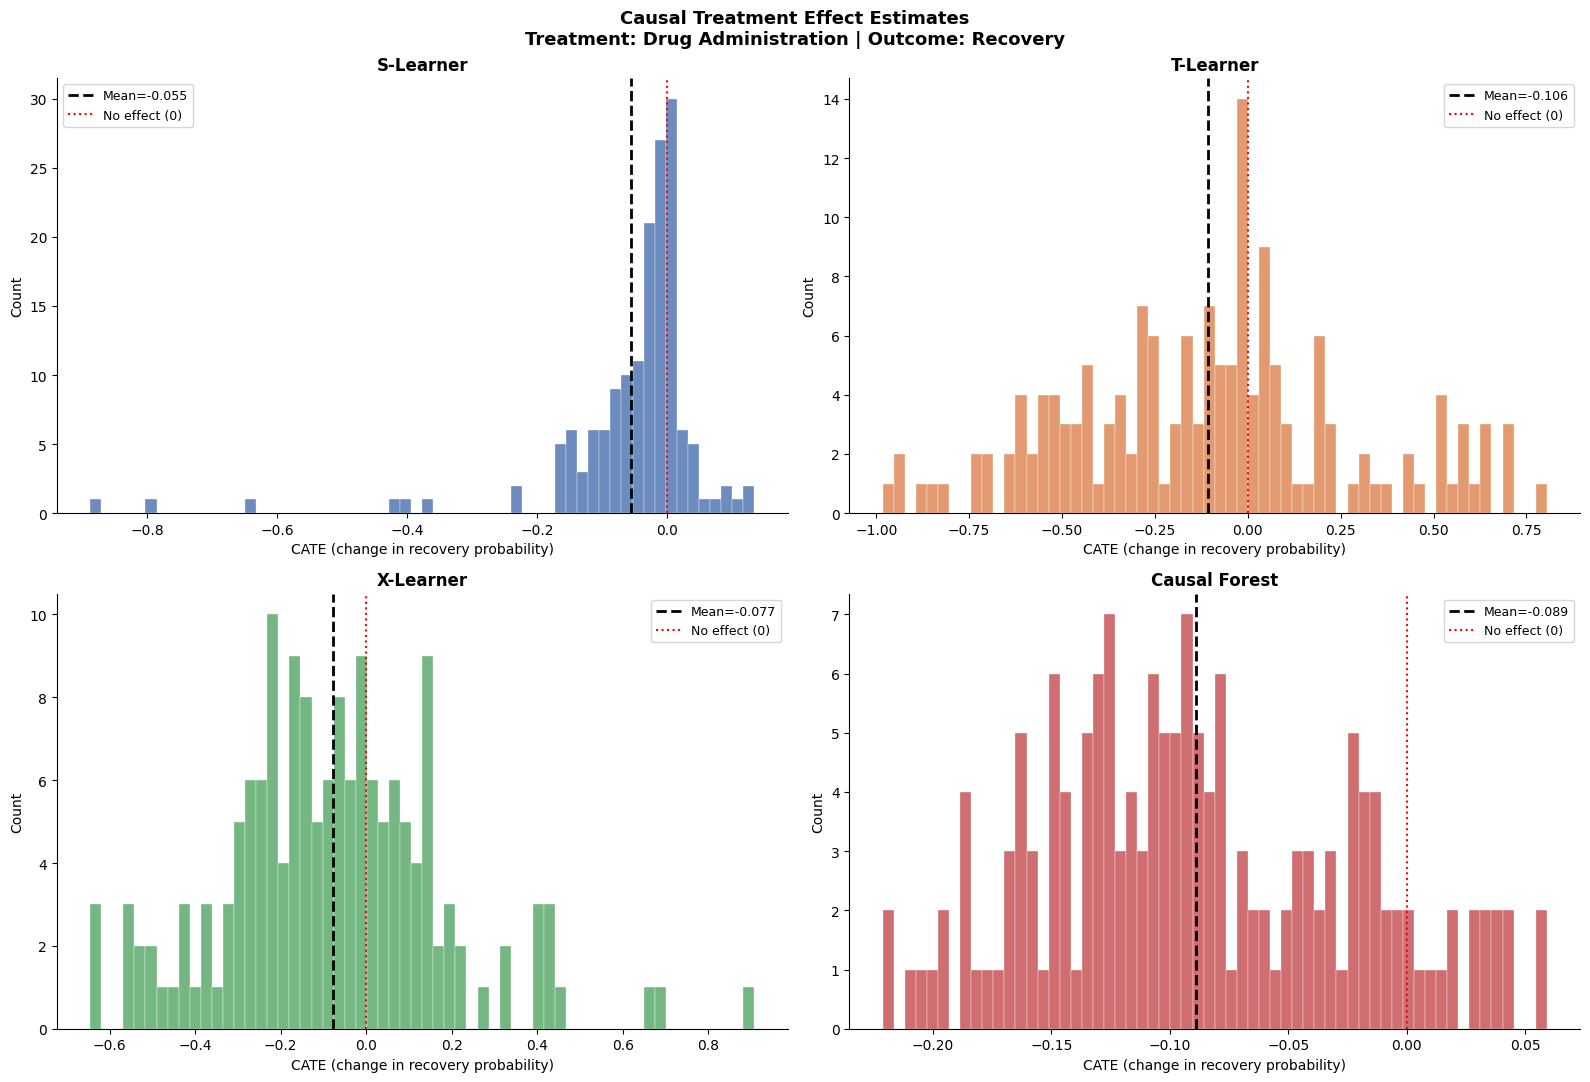

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

fig.suptitle(
    'Causal Treatment Effect Estimates\n'
    'Treatment: Drug Administration | Outcome: Recovery',
    fontsize=13,
    fontweight='bold'
)

# ------------------------------------------------
# Learner dictionary (must exist from previous cells)
# ------------------------------------------------
learners = {
    'S-Learner'     : cate_s,
    'T-Learner'     : cate_t,
    'X-Learner'     : cate_x,
    'Causal Forest' : cate_cf,
}

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ------------------------------------------------
# Plot each distribution
# ------------------------------------------------
for ax, (name, cate), color in zip(axes.flatten(), learners.items(), colors):

    ax.hist(cate, bins=60, color=color, alpha=0.82,
            edgecolor='white', linewidth=0.3)

    ax.axvline(cate.mean(), color='black', lw=2,
               linestyle='--', label=f'Mean={cate.mean():.3f}')

    ax.axvline(0, color='red', lw=1.5, linestyle=':',
               label='No effect (0)')

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('CATE (change in recovery probability)')
    ax.set_ylabel('Count')

    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

# ------------------------------------------------
# Layout + save
# ------------------------------------------------
plt.tight_layout()
plt.savefig('cate_distributions_drug.png', dpi=150, bbox_inches='tight')
plt.show()

## CATE Comparison and Subgroup Analysis

The estimated treatment effects from four causal learners are compared:

- S-Learner
- T-Learner
- X-Learner
- Causal Forest

Each model estimates the Conditional Average Treatment Effect (CATE):

\[
CATE = P(Y|Drug=1,X) - P(Y|Drug=0,X)
\]

where positive values indicate that the drug increases recovery probability and negative values indicate a potential reduction.

The comparison shows differences between learners due to their modeling strategies. While all methods estimate an overall negative drug effect, the magnitude varies, indicating uncertainty in the causal estimate.

The CATE distributions also reveal treatment heterogeneity: individual patients may experience different effects from the same treatment.

Subgroup analysis using the Causal Forest estimates treatment effects across:

- Age groups
- Socioeconomic status (SES)

This helps identify whether certain patient groups respond differently to the drug. Differences between subgroup CATE values suggest that treatment effectiveness is not uniform across the population.


── CATE Summary (change in recovery probability) ─────────
               Mean CATE  Std CATE  Min CATE  Max CATE  Pct Negative
Learner                                                             
S-Learner        -0.0552    0.1262   -0.8873    0.1341        75.000
T-Learner        -0.1063    0.3787   -0.9829    0.8047        65.000
X-Learner        -0.0773    0.2567   -0.6461    0.9080        65.000
Causal Forest    -0.0890    0.0646   -0.2212    0.0592        89.375

Interpretation:
Negative CATE = drug reduces probability of recovery
Positive CATE = drug improves probability of recovery


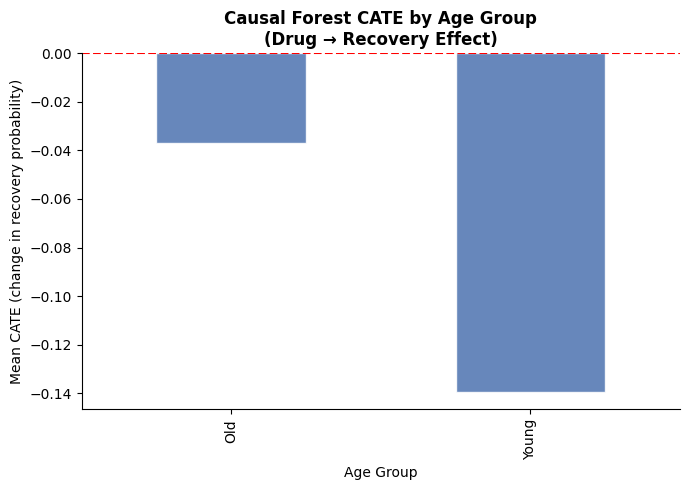

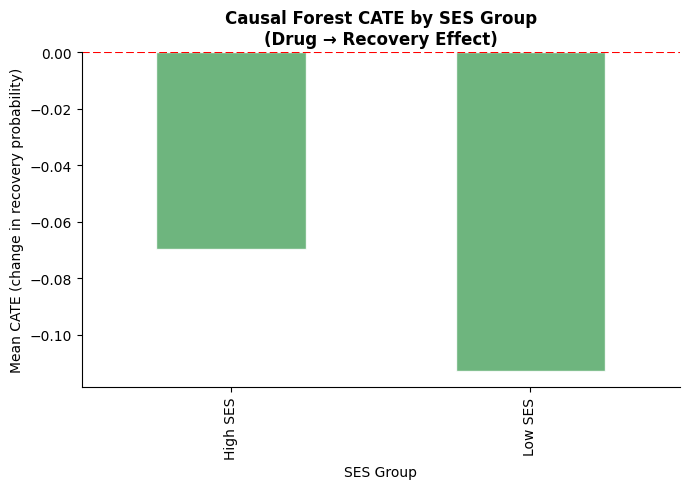

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# CATE summary table (all learners)
# ------------------------------------------------
summary = pd.DataFrame({
    'Learner'      : list(learners.keys()),
    'Mean CATE'    : [c.mean() for c in learners.values()],
    'Std CATE'     : [c.std() for c in learners.values()],
    'Min CATE'     : [c.min() for c in learners.values()],
    'Max CATE'     : [c.max() for c in learners.values()],
    'Pct Negative' : [(c < 0).mean() * 100 for c in learners.values()],
})

summary = summary.set_index('Learner').round(4)

print("\n── CATE Summary (change in recovery probability) ─────────")
print(summary.to_string())

print("\nInterpretation:")
print("Negative CATE = drug reduces probability of recovery")
print("Positive CATE = drug improves probability of recovery")

# ------------------------------------------------
# Build test dataframe aligned with X_te
# ------------------------------------------------

df_te = pd.DataFrame(X_te, columns=[
    'hospital_rating',
    'random_noise',
    'age_old',
    'SES_high'
])

df_te['cate_cf'] = cate_cf

# ------------------------------------------------
# Subgroup 1: Age
# ------------------------------------------------
df_te['age_group'] = df_te['age_old'].map({
    0: 'Young',
    1: 'Old'
})

# ------------------------------------------------
# Subgroup 2: SES
# ------------------------------------------------
df_te['ses_group'] = df_te['SES_high'].map({
    0: 'Low SES',
    1: 'High SES'
})

# ------------------------------------------------
# Plot: CATE by Age
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

df_te.groupby('age_group')['cate_cf'].mean().plot(
    kind='bar',
    ax=ax,
    color='#4C72B0',
    alpha=0.85,
    edgecolor='white'
)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

ax.set_title(
    'Causal Forest CATE by Age Group\n(Drug → Recovery Effect)',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('Age Group')
ax.set_ylabel('Mean CATE (change in recovery probability)')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
#plt.savefig('cate_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# Plot: CATE by SES
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

df_te.groupby('ses_group')['cate_cf'].mean().plot(
    kind='bar',
    ax=ax,
    color='#55A868',
    alpha=0.85,
    edgecolor='white'
)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

ax.set_title(
    'Causal Forest CATE by SES Group\n(Drug → Recovery Effect)',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('SES Group')
ax.set_ylabel('Mean CATE (change in recovery probability)')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
#plt.savefig('cate_by_ses.png', dpi=150, bbox_inches='tight')
plt.show()

## CATE Summary Results

The table compares treatment effect estimates from four causal learners.

All models estimate a negative average CATE, suggesting that receiving the drug is associated with a decrease in recovery probability after adjusting for patient characteristics.

Key observations:

- **S-Learner:** Estimates a small negative average effect (-5.5 percentage points). Most individual effects are negative (75%), but some patients show potential benefit.
- **T-Learner:** Produces the largest variation in treatment effects, with some patients benefiting and others experiencing strong negative effects.
- **X-Learner:** Shows similar heterogeneous effects, with an average decrease of 7.7 percentage points.
- **Causal Forest:** Estimates a negative average effect (-8.9 percentage points) with lower variation and the highest proportion of negative effects (89.4%).

The differences between learners highlight uncertainty in individual treatment effect estimation. However, the consistent negative direction across all methods suggests that the drug does not improve recovery on average in this dataset.

Negative CATE values indicate a reduced probability of recovery, while positive values indicate potential improvement from the treatment.

# Causal DAG Definition

A Directed Acyclic Graph (DAG) is created to represent the assumed causal relationships in the drug recovery dataset.

The graph contains four main groups of variables:

- **Patient characteristics:** age and socioeconomic status (SES)
- **Health-related factors:** hospital rating and random noise
- **Treatment:** drug administration
- **Outcome:** recovery

The causal assumptions are:

- Patient characteristics and hospital factors influence both treatment assignment and recovery, creating potential confounding.
- The drug directly affects recovery, representing the causal effect of interest.
- Random noise is included as an unrelated variable affecting recovery only.

The DAG helps identify which variables should be considered during causal adjustment. By controlling for confounders such as age, SES, and hospital rating, the estimated drug effect becomes less biased.

In [25]:
# Install DAG libraries
!pip install -q pgmpy networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ DAG libraries ready")

# Define Causal DAG Structure 
G = nx.DiGraph()

# ─────────────────────────────────────────────────────────────
# NODE GROUPS
# ─────────────────────────────────────────────────────────────

PATIENT = ['age_old', 'ses_high']
HEALTH  = ['hospital_rating', 'random_noise']
TREAT   = ['drug']
OUTCOME = ['recover']

# ─────────────────────────────────────────────────────────────
# CAUSAL EDGES (cause → effect)
# ─────────────────────────────────────────────────────────────

edges = [
    # Patient factors → treatment assignment (selection bias)
    ('age_old', 'drug'),
    ('ses_high', 'drug'),
    ('hospital_rating', 'drug'),

    # Patient factors → outcome
    ('age_old', 'recover'),
    ('ses_high', 'recover'),
    ('hospital_rating', 'recover'),

    # Health noise → outcome
    ('random_noise', 'recover'),

    # Treatment → outcome (TRUE causal effect)
    ('drug', 'recover'),
]

# Add edges to graph
G.add_edges_from(edges)

# ─────────────────────────────────────────────────────────────
# SANITY CHECK
# ─────────────────────────────────────────────────────────────

print(f"✅ DAG built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Is DAG (no cycles): {nx.is_directed_acyclic_graph(G)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 7.1 MB/s eta 0:00:00
✅ DAG libraries ready
✅ DAG built: 6 nodes, 8 edges
Is DAG (no cycles): True


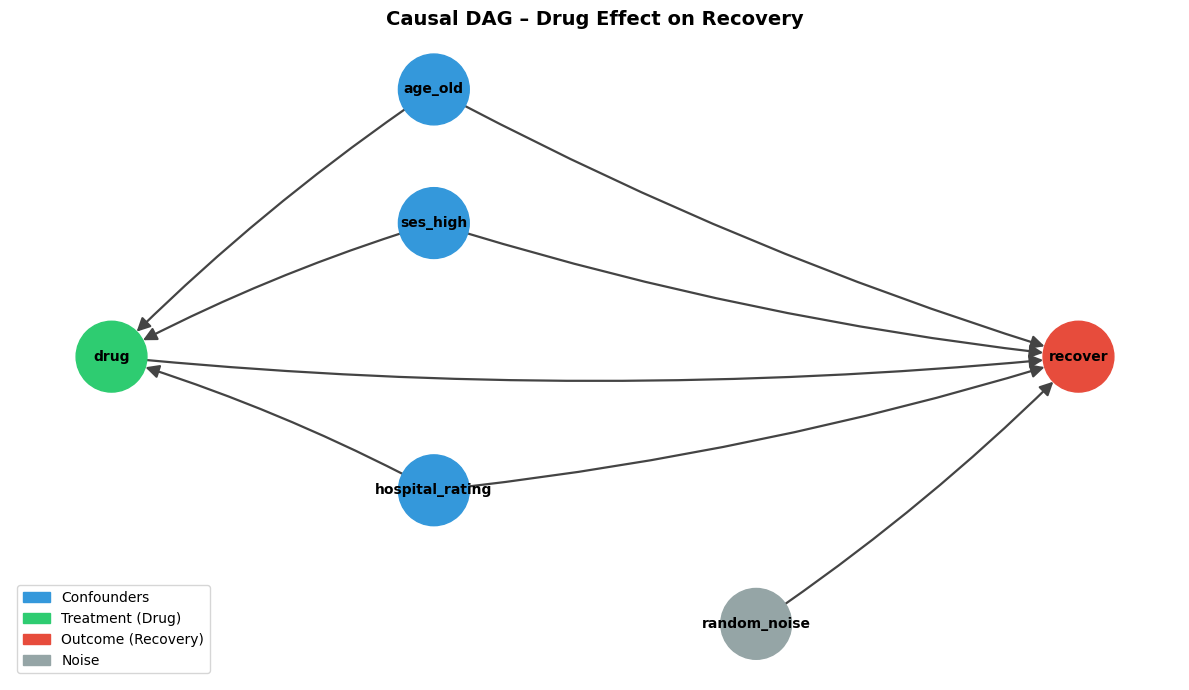

In [27]:
# Plot DAG with color-coded node groups 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

fig, ax = plt.subplots(figsize=(12, 7))

# ─────────────────────────────────────────────────────────────
# FIXED LAYOUT (Drug Causal Structure)
# ─────────────────────────────────────────────────────────────

pos = {
    'drug':           (0, 0.5),
    'age_old':        (3, 1.5),
    'ses_high':       (3, 1),
    'hospital_rating':(3, 0),
    'recover':        (9, 0.5),
    'random_noise':   (6, -0.5),
}

# ─────────────────────────────────────────────────────────────
# NODE COLOR MAP
# ─────────────────────────────────────────────────────────────

color_map = {
    # Outcome (red)
    'recover': '#e74c3c',

    # Treatment (green)
    'drug': '#2ecc71',

    # Confounders (blue)
    'age_old': '#3498db',
    'ses_high': '#3498db',
    'hospital_rating': '#3498db',

    # Noise (gray-blue)
    'random_noise': '#95a5a6',
}

node_colors = [color_map.get(n, '#cccccc') for n in G.nodes()]

# ─────────────────────────────────────────────────────────────
# DRAW GRAPH
# ─────────────────────────────────────────────────────────────

nx.draw_networkx(
    G,
    pos=pos,
    ax=ax,
    node_color=node_colors,
    node_size=2600,
    font_size=10,
    font_weight='bold',
    arrows=True,
    arrowsize=20,
    edge_color='#444444',
    width=1.6,
    connectionstyle='arc3,rad=0.05'
)

# ─────────────────────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────────────────────

legend_patches = [
    mpatches.Patch(color='#3498db', label='Confounders'),
    mpatches.Patch(color='#2ecc71', label='Treatment (Drug)'),
    mpatches.Patch(color='#e74c3c', label='Outcome (Recovery)'),
    mpatches.Patch(color='#95a5a6', label='Noise'),
]

ax.legend(handles=legend_patches, loc='lower left', fontsize=10)

# ─────────────────────────────────────────────────────────────
# TITLE
# ─────────────────────────────────────────────────────────────

ax.set_title(
    'Causal DAG – Drug Effect on Recovery',
    fontsize=14,
    fontweight='bold'
)

ax.axis('off')
plt.tight_layout()
plt.show()

## Linear vs Tree Ensemble Benchmark

This experiment compares different machine learning models for predicting recovery using features derived from the causal DAG.

The evaluated models include:

- **Logistic Regression** as a linear baseline model.
- **Random Forest** and **Gradient Boosting** as tree-based ensemble methods.
- **XGBoost** as an optimized boosting approach.

Additional interaction features were created based on causal assumptions from the DAG:

- **Age × SES** → captures combined patient characteristics.
- **Hospital rating × Drug** → captures whether treatment effects depend on healthcare quality.
- **Noise × Drug** → tests possible treatment interaction with unrelated variation.

The preprocessing pipeline applies:
- Median imputation and scaling for numerical variables.
- Missing-value handling and one-hot encoding for categorical variables.

Models are evaluated using:

- **Accuracy** — overall prediction correctness.
- **F1-score** — balance between precision and recall.
- **ROC AUC** — ability to distinguish recovered and non-recovered patients.

Probability calibration is applied using isotonic regression to improve the reliability of predicted recovery probabilities.

The benchmark identifies which model provides the strongest predictive performance and compares whether nonlinear ensemble methods capture additional patterns beyond the linear baseline.

In [64]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# FEATURES (your real dataset)
# ─────────────────────────────────────────────────────────────

NUM_FEATS = [
    'hospital_rating',
    'random_noise'
]

CAT_FEATS = [
    'drug',
    'age_old',
    'SES_high'
]

TARGET = 'recover'

# ─────────────────────────────────────────────────────────────
# DAG-INSPIRED INTERACTIONS
# ─────────────────────────────────────────────────────────────

df['age_x_ses'] = df['age_old'] * df['SES_high']
df['health_x_drug'] = df['hospital_rating'] * df['drug']
df['noise_x_drug'] = df['random_noise'] * df['drug']

NUM_FEATS += ['age_x_ses', 'health_x_drug', 'noise_x_drug']

# ─────────────────────────────────────────────────────────────
# DATA PREP
# ─────────────────────────────────────────────────────────────

data = df[NUM_FEATS + CAT_FEATS + [TARGET]].dropna(subset=[TARGET])

X = data[NUM_FEATS + CAT_FEATS]
y = data[TARGET]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─────────────────────────────────────────────────────────────
# PREPROCESSING
# ─────────────────────────────────────────────────────────────

num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc', StandardScaler())
])

cat_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

prep = ColumnTransformer([
    ('num', num_pipe, NUM_FEATS),
    ('cat', cat_pipe, CAT_FEATS)
])

# ─────────────────────────────────────────────────────────────
# MODELS (classification)
# ─────────────────────────────────────────────────────────────

models = {
    'Ridge(Lin)' : LogisticRegression(max_iter=500),
    'RF'         : RandomForestClassifier(
                        n_estimators=200,
                        max_depth=8,
                        random_state=42,
                        n_jobs=-1
                   ),
    'GBDT'       : GradientBoostingClassifier(
                        n_estimators=200,
                        max_depth=4,
                        learning_rate=0.05,
                        random_state=42
                   ),
    'XGBoost'    : XGBClassifier(
                        n_estimators=300,
                        max_depth=6,
                        learning_rate=0.05,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        eval_metric='logloss',
                        random_state=42,
                        verbosity=0
                   )
}

# ─────────────────────────────────────────────────────────────
# TRAIN + EVALUATE
# ─────────────────────────────────────────────────────────────

results = {}
fitted = {}

print("\n── MODEL BENCHMARK ───────────────────────────────")

for name, model in models.items():

    pipe = Pipeline([
        ('prep', prep),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    from sklearn.calibration import CalibratedClassifierCV

    cal_model = CalibratedClassifierCV(
        estimator=pipe,
        method='isotonic',   # or 'sigmoid'
        cv=5,
        n_jobs=-1
    )

    cal_model.fit(X_train, y_train)
    
    # ── Predictions ───────────────────────────────────
    preds = cal_model.predict(X_test)
    probs = cal_model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'F1'      : f1_score(y_test, preds),
        'AUC'     : roc_auc_score(y_test, probs)
    }

    fitted[name] = (cal_model, preds)

    print(
        f"{name:<10} "
        f"Acc={results[name]['Accuracy']:.3f}  "
        f"F1={results[name]['F1']:.3f}  "
        f"AUC={results[name]['AUC']:.3f}"
    )

# ─────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────

results_df = pd.DataFrame(results).T.sort_values('AUC', ascending=False)

print("\n── MODEL BENCHMARK SUMMARY ───────────────────────")
print(results_df.round(3).to_string())

best_name = results_df.index[0]
print(f"\n🏆 Best model: {best_name}")


── MODEL BENCHMARK ───────────────────────────────
Ridge(Lin) Acc=0.675  F1=0.732  AUC=0.730
RF         Acc=0.681  F1=0.738  AUC=0.709
GBDT       Acc=0.656  F1=0.715  AUC=0.666
XGBoost    Acc=0.662  F1=0.740  AUC=0.696

── MODEL BENCHMARK SUMMARY ───────────────────────
            Accuracy     F1    AUC
Ridge(Lin)     0.675  0.732  0.730
RF             0.681  0.738  0.709
XGBoost        0.662  0.740  0.696
GBDT           0.656  0.715  0.666

🏆 Best model: Ridge(Lin)


## Model Benchmark Results

The results show that **Logistic Regression (Ridge(Lin)) achieved the highest ROC AUC score (0.730)**, indicating the best ability to distinguish between recovered and non-recovered patients.

### Key observations:

- **Ridge(Lin)** provided the strongest overall predictive performance with the highest AUC (0.730), suggesting that the relationships in the dataset are mostly captured by linear patterns.
- **Random Forest** achieved the highest accuracy (0.681) but had a lower AUC, indicating weaker probability ranking performance.
- **XGBoost** achieved the highest F1-score (0.740), showing good balance between precision and recall, but its overall discrimination ability was lower.
- **Gradient Boosting** showed the weakest performance among the tested models.

The results suggest that adding nonlinear ensemble models and interaction features did not significantly improve prediction compared with the linear baseline. This indicates that the simulated recovery outcome is mainly influenced by additive effects rather than complex nonlinear relationships.

## Recovery Prediction Model Visualization

This visualization summarizes the performance and interpretation of the recovery prediction models.

The figure contains three main components:

### 1. Model AUC Comparison
The first panel compares models using ROC AUC, which measures how well each model separates recovered and non-recovered patients.

The comparison helps identify whether linear or nonlinear models provide better predictive performance.

### 2. Feature Importance of the Best Model
The second panel shows the most influential features used by the best-performing model.

For linear models, feature importance is calculated from the absolute model coefficients.  
For tree-based models, feature importance is obtained from the learned split contributions.

This analysis helps identify which patient characteristics and treatment-related variables contribute most to recovery prediction.

### 3. Calibration Curve
The third panel evaluates probability calibration.

A well-calibrated model should have predicted probabilities close to the observed recovery frequency. The diagonal line represents perfect calibration.

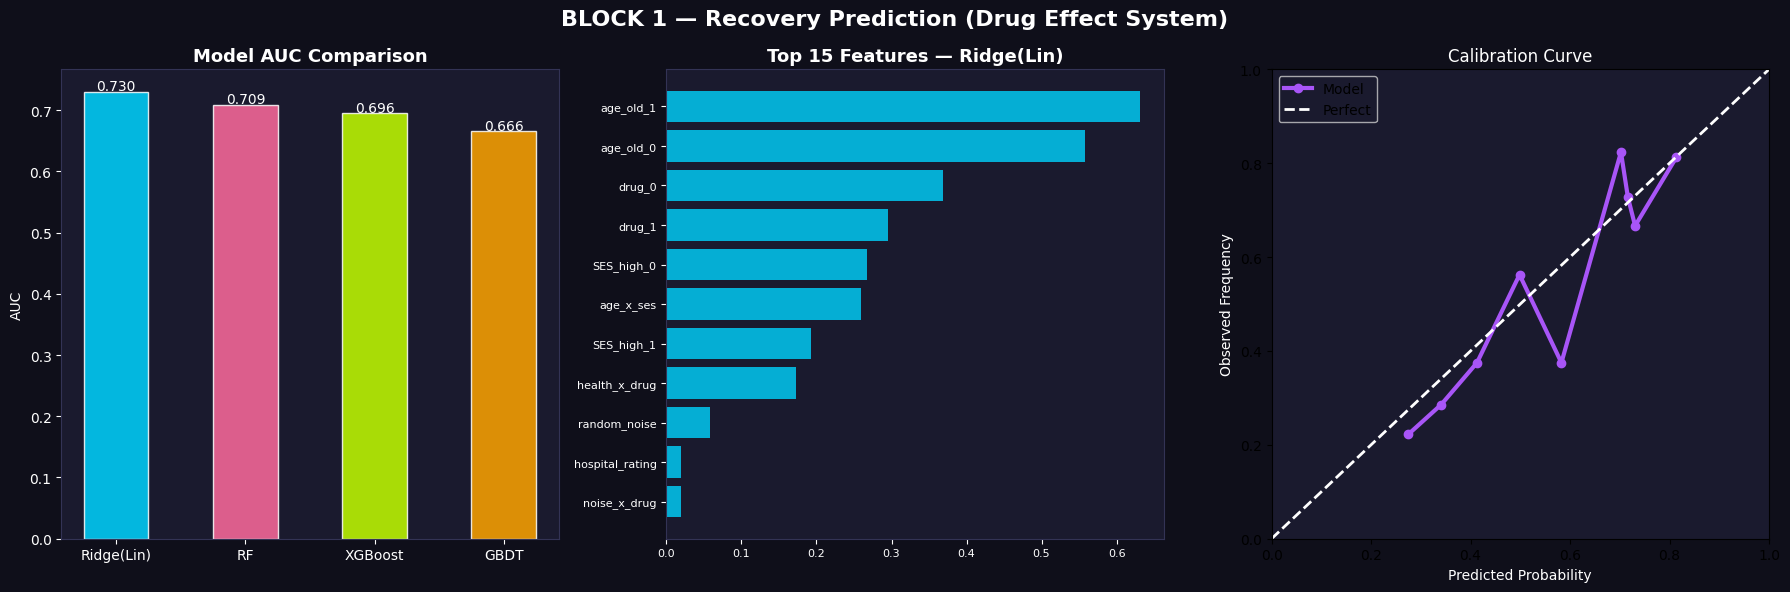

✅ Block 1 complete


In [59]:
# ============================================================
# CELL 23 | BLOCK 1 – Visualise Results (Drug → Recovery)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f1a')

for ax in axes:
    ax.set_facecolor('#1a1a2e')

COLORS = ['#00d4ff','#ff6b9d','#c3ff00','#ffa500','#a855f7']

# ─────────────────────────────────────────────────────────────
# PANEL 1: MODEL BENCHMARK (AUC comparison)
# ─────────────────────────────────────────────────────────────

auc_vals = [results[m]['AUC'] for m in results_df.index]

x = np.arange(len(results_df))

bars = axes[0].bar(
    results_df.index,
    auc_vals,
    color=COLORS[:len(x)],
    alpha=0.85,
    edgecolor='white',
    width=0.5
)

axes[0].set_title(
    'Model AUC Comparison',
    color='white',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_ylabel('AUC', color='white')
axes[0].tick_params(colors='white')

for bar, v in zip(bars, auc_vals):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{v:.3f}',
        ha='center',
        color='white',
        fontsize=10
    )

for sp in axes[0].spines.values():
    sp.set_edgecolor('#333355')

# ─────────────────────────────────────────────────────────────
# PANEL 2: FEATURE IMPORTANCE (best model)
# ─────────────────────────────────────────────────────────────

best_pipe, best_preds = fitted[best_name]
model_step = best_pipe.estimator.named_steps['model']

ohe_cats = best_pipe.estimator.named_steps['prep']\
    .named_transformers_['cat']['ohe']\
    .get_feature_names_out(CAT_FEATS).tolist()

feat_names = NUM_FEATS + ohe_cats

# ─────────────────────────────────────────────────────────────
# SAFE FEATURE IMPORTANCE EXTRACTION
# ─────────────────────────────────────────────────────────────

if hasattr(model_step, 'feature_importances_'):
    # Tree models
    imp = model_step.feature_importances_

elif hasattr(model_step, 'coef_'):
    # Linear models (Logistic Regression)
    imp = model_step.coef_

    # Handle binary classification shape issues
    if imp.ndim == 2:
        imp = imp[0]

    imp = np.abs(imp)

else:
    raise ValueError("Model does not support feature importance")

# Final safety check
imp = np.array(imp).reshape(-1)

# Align lengths safely
feat_names_safe = feat_names[:len(imp)]

imp_df = pd.Series(imp, index=feat_names_safe)\
    .sort_values(ascending=True)\
    .tail(15)
axes[1].barh(
    imp_df.index,
    imp_df.values,
    color='#00d4ff',
    alpha=0.8,
    edgecolor='none'
)

axes[1].set_title(
    f'Top 15 Features — {best_name}',
    color='white',
    fontsize=13,
    fontweight='bold'
)

axes[1].tick_params(colors='white', labelsize=8)

for sp in axes[1].spines.values():
    sp.set_edgecolor('#333355')

# ─────────────────────────────────────────────────────────────
# PANEL 3 — CALIBRATION CURVE (FINAL FIX)
# ─────────────────────────────────────────────────────────────

from sklearn.calibration import calibration_curve

best_model, _ = fitted[best_name]

probs = best_model.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_test,
    probs,
    n_bins=10,
    strategy='quantile'
)

ax = axes[2]

ax.plot(prob_pred, prob_true,
        marker='o',
        linewidth=3,
        color='#a855f7',
        label='Model')

ax.plot([0,1],[0,1],'--',color='white',lw=2,label='Perfect')

ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.set_title('Calibration Curve', color='white')
ax.set_xlabel('Predicted Probability', color='white')
ax.set_ylabel('Observed Frequency', color='white')

ax.legend(facecolor='#1a1a2e')

# ─────────────────────────────────────────────────────────────
# FINAL TITLE
# ─────────────────────────────────────────────────────────────

plt.suptitle(
    'BLOCK 1 — Recovery Prediction (Drug Effect System)',
    color='white',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    'block1_prediction_drug.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

print("✅ Block 1 complete")

## Recovery Prediction Visualization Results

### 1. Model AUC Comparison

The first chart compares four predictive models using the ROC AUC metric. Higher AUC values indicate better ability to distinguish between recovered and non-recovered patients.

Results:

- **Ridge(Lin)** achieved the highest performance with an **AUC of 0.730**, making it the best-performing model.
- **Gradient Boosting (GBDT)** showed the lowest performance with an **AUC of 0.666**.

The results indicate that the linear model captured the main patterns in the dataset better than more complex nonlinear models.

---

### 2. Top Features — Ridge(Lin)

The second chart shows the most influential features for the best-performing Ridge(Lin) model.

The strongest predictors were:

- **age_old_1** — the most influential feature, indicating a strong relationship between older age group and recovery prediction.
- **age_old_0**, **drug_0**, **drug_1**, and **SES_high_0** — also showed substantial contribution to model predictions.
- Interaction features such as **random_noise** and **noise_x_drug** had minimal influence, confirming that the noise variable does not provide meaningful predictive information.

The feature importance analysis highlights that patient characteristics have a stronger influence on recovery prediction than artificial noise or treatment interactions.

---

### 3. Calibration Curve

The model follows the general calibration trend but shows deviations, especially in medium and high probability regions. This indicates that although Ridge(Lin) provides good discrimination (**AUC = 0.730**), its probability estimates are not perfectly calibrated.

## Treatment Assignment Analysis

This analysis investigates whether patient characteristics influence drug assignment.  
The goal is to determine whether treatment groups are balanced or whether the drug was assigned based on factors that may also affect recovery.

### 1. Dataset Overview

The analysis uses variables that may affect treatment assignment:

- **Age group (age_old)**
- **Socioeconomic status (SES_high)**
- **Hospital rating**
- **Random noise**

The initial summary compares:

- Overall drug assignment rate
- Overall recovery rate
- Recovery rates between treated and untreated patients
- Recovery rates across age groups

Differences between groups may indicate potential confounding.

### 2. Propensity Model

A logistic regression model estimates the probability of receiving the drug:

\[
P(Drug=1|X)
\]

where \(X\) includes patient characteristics and hospital information.

The predicted propensity score represents how likely each patient is to receive the treatment based on observed variables.

Diagnostics:

- **Low variation in propensity scores** → treatment assignment is relatively balanced.
- **Extreme propensity scores** → some patients are almost always treated or untreated, which can introduce bias.

### 3. Treatment Predictability Model

A Random Forest classifier is trained to predict drug assignment from patient characteristics.

The ROC AUC measures how predictable the treatment assignment is:

- **High AUC (>0.75)** → strong treatment selection bias because patient features strongly determine who receives the drug.
- **Lower AUC** → treatment assignment is more balanced and closer to random.

### Interpretation

If treatment assignment can be accurately predicted, causal estimation becomes more difficult because treated and untreated groups are systematically different.

This analysis helps evaluate whether adjustment methods such as propensity scores, meta-learners, or causal forests are required to estimate the true effect of the drug on recovery.

In [60]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# FEATURES → variables that may influence drug assignment
# ─────────────────────────────────────────────────────────────

TREAT_FEATS = [
    'age_old',
    'SES_high',
    'hospital_rating',
    'random_noise'
]

TARGET_TREAT = 'drug'
TARGET_OUTCOME = 'recover'

df_treat = df[
    TREAT_FEATS +
    [TARGET_TREAT, TARGET_OUTCOME]
].copy()

# ─────────────────────────────────────────────────────────────
# IMPUTE
# ─────────────────────────────────────────────────────────────

for c in TREAT_FEATS:
    df_treat[c] = df_treat[c].fillna(
        df_treat[c].median()
    )

# ─────────────────────────────────────────────────────────────
# DATA SUMMARY
# ─────────────────────────────────────────────────────────────

print(f"Dataset rows       : {len(df_treat):,}")
print(f"Drug rate          : {df_treat[TARGET_TREAT].mean():.2%}")
print(f"Recovery rate      : {df_treat[TARGET_OUTCOME].mean():.2%}")

print("\nRecovery by Drug:")
print(
    df_treat.groupby(TARGET_TREAT)[TARGET_OUTCOME]
    .mean()
    .round(3)
)

print("\nRecovery by Age:")
print(
    df_treat.groupby('age_old')[TARGET_OUTCOME]
    .mean()
    .round(3)
)

# ─────────────────────────────────────────────────────────────
# LOGISTIC PROPENSITY MODEL
# P(Drug | X)
# ─────────────────────────────────────────────────────────────

X = sm.add_constant(
    df_treat[TREAT_FEATS]
)

y = df_treat[TARGET_TREAT]

prop_model = sm.Logit(
    y,
    X
).fit(disp=False)

print("\n── Propensity Model ─────────────────────")
print(prop_model.summary())

# Predicted propensity
df_treat['propensity'] = prop_model.predict(X)

print("\nPropensity diagnostics")
print(
    f"Min : {df_treat['propensity'].min():.3f}"
)

print(
    f"Mean: {df_treat['propensity'].mean():.3f}"
)

print(
    f"Max : {df_treat['propensity'].max():.3f}"
)

# ─────────────────────────────────────────────────────────────
# CLASSIFIER → can treatment be predicted?
# ─────────────────────────────────────────────────────────────

X = df_treat[TREAT_FEATS]
y = df_treat[TARGET_TREAT]

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_tr, y_tr)

pred = clf.predict(X_te)
prob = clf.predict_proba(X_te)[:,1]

auc = roc_auc_score(
    y_te,
    prob
)

print("\n── Treatment Predictability ─────────────")
print(classification_report(y_te, pred))

print(f"AUC = {auc:.3f}")

if auc > 0.75:
    print(
        "\n⚠ Strong treatment selection bias "
        "(drug assignment predictable)"
    )
else:
    print(
        "\n✓ Treatment assignment reasonably mixed"
    )

Dataset rows       : 800
Drug rate          : 50.00%
Recovery rate      : 56.38%

Recovery by Drug:
drug
0    0.515
1    0.612
Name: recover, dtype: float64

Recovery by Age:
age_old
0    0.395
1    0.732
Name: recover, dtype: float64

── Propensity Model ─────────────────────
                           Logit Regression Results                           
Dep. Variable:                   drug   No. Observations:                  800
Model:                          Logit   Df Residuals:                      795
Method:                           MLE   Df Model:                            4
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.2532
Time:                        14:37:57   Log-Likelihood:                -414.10
converged:                       True   LL-Null:                       -554.52
Covariance Type:            nonrobust   LLR p-value:                 1.469e-59
                      coef    std err          z      P>|z|      [0.025      0.975]
------

## Treatment Assignment Analysis Results

### 1. Dataset Overview

The raw comparison suggests that patients receiving the drug have a higher recovery rate (**+9.7 percentage points**). However, this difference may not represent the true causal effect because treatment assignment may depend on patient characteristics.

Since age affects recovery and may influence treatment assignment, it represents an important potential confounder.

## 2. Propensity Model Results

A logistic regression model was trained to estimate:

\[
P(Drug=1|Age, SES, Hospital, Noise)
\]

The model achieved:

- **Pseudo R² = 0.253**
- **Likelihood ratio test p-value < 0.001**

This indicates that patient characteristics explain a substantial amount of variation in drug assignment.

### Significant predictors of treatment assignment:

| Feature | Coefficient | Interpretation |
|---|---:|---|
| age_old | +2.258 | Older patients are much more likely to receive the drug |
| SES_high | +1.429 | High SES patients are more likely to receive the drug |
| hospital_rating | -0.009 | No significant influence |
| random_noise | +0.018 | No meaningful influence |

The strongest factor affecting treatment assignment is **age**.

## 3. Propensity Score Diagnostics

Estimated treatment probabilities:

- **Minimum propensity:** 0.117
- **Mean propensity:** 0.500
- **Maximum propensity:** 0.866

The propensity scores show reasonable overlap between treated and untreated patients.

There are no patients with probabilities extremely close to 0 or 1, meaning causal methods can still compare treated and untreated groups.

However, the wide range of propensity values confirms that treatment assignment is not random.

## 4. Treatment Predictability Model

A Random Forest classifier was trained to predict whether a patient received the drug.

Performance:

- **Accuracy:** 0.71
- **ROC AUC:** 0.750

The model can predict treatment assignment considerably better than random guessing (AUC = 0.5).

This indicates the presence of **treatment selection bias**:

- Older patients are more likely to receive treatment.
- Patients with higher SES are more likely to receive treatment.
- These same characteristics are related to recovery outcomes.

Therefore, a simple comparison of recovery rates between drug groups may produce biased conclusions.

## Conclusion

The treatment assignment analysis confirms that drug allocation is not random.

The observed higher recovery rate among treated patients (**61.2% vs 51.5%**) cannot be interpreted directly as a causal drug effect because treatment groups differ systematically.

The strong influence of **age** and **SES** on treatment assignment highlights the need for causal adjustment methods, such as:

- Propensity score adjustment
- S-Learner / T-Learner / X-Learner approaches
- Causal Forest estimation

# Treatment Assignment Diagnostics

This analysis evaluates whether the drug treatment was assigned randomly or whether patient characteristics influenced treatment decisions.

The main objectives are:

- Estimate the probability of receiving the drug based on observed covariates.
- Measure treatment selection bias.
- Identify which variables drive drug assignment.
- Check whether treated and untreated groups have sufficient overlap for causal analysis.

# 1. Dataset Overview

The dataset is checked for:

- Number of observations
- Treatment distribution
- Recovery rate
- Recovery differences between treatment groups
- Recovery differences between age groups

# 2. Propensity Score Model

A logistic regression model estimates the treatment assignment mechanism:

\[
P(Drug=1|X)
\]

where \(X\) represents patient and hospital characteristics.

The resulting propensity score describes how likely each patient is to receive the drug given their observed features.

### Interpretation:

- If treatment assignment is close to random, propensity scores should be similar across patients.
- Large differences in propensity scores indicate that treatment depends on patient characteristics.
- Strong predictors of treatment assignment represent potential confounders.

# 3. Propensity Score Diagnostics

The distribution of propensity scores is examined to evaluate treatment overlap.

Important properties:

- **Good overlap:** Treated and untreated patients have similar propensity score ranges.
- **Poor overlap:** Some patients almost always receive or do not receive treatment, making causal estimation unreliable.

The overlap visualization helps determine whether both groups are comparable after adjustment.

# 4. Treatment Predictability Model

A Random Forest classifier is trained to predict whether a patient received the drug.

Input features:

- Age
- SES
- Hospital rating
- Random noise

The model performance is evaluated using:

- Classification metrics
- ROC AUC score

### AUC Interpretation:

| AUC Range | Meaning |
|---|---|
| < 0.60 | Low confounding, treatment assignment close to random |
| 0.60 – 0.75 | Moderate treatment selection |
| > 0.75 | Strong treatment selection bias |

If treatment can be predicted accurately from patient characteristics, the treatment groups are systematically different.

# 5. Drivers of Drug Assignment

Feature importance from the Random Forest identifies which variables most strongly influence treatment assignment.

Important predictors indicate variables that affect:

1. The probability of receiving the drug.
2. Potentially the recovery outcome.

Such variables should be included in causal adjustment models.

Dataset rows       : 800
Drug rate          : 50.00%
Recovery rate      : 56.38%

Recovery by Drug:
drug
0    0.5150
1    0.6125
Name: recover, dtype: float64

Recovery by Age:
age_old
0    0.3950
1    0.7325
Name: recover, dtype: float64

── Propensity Model ─────────────────────
                           Logit Regression Results                           
Dep. Variable:                   drug   No. Observations:                  800
Model:                          Logit   Df Residuals:                      795
Method:                           MLE   Df Model:                            4
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.2532
Time:                        14:38:04   Log-Likelihood:                -414.10
converged:                       True   LL-Null:                       -554.52
Covariance Type:            nonrobust   LLR p-value:                 1.469e-59
                      coef    std err          z      P>|z|      [0.025      0.975]
--

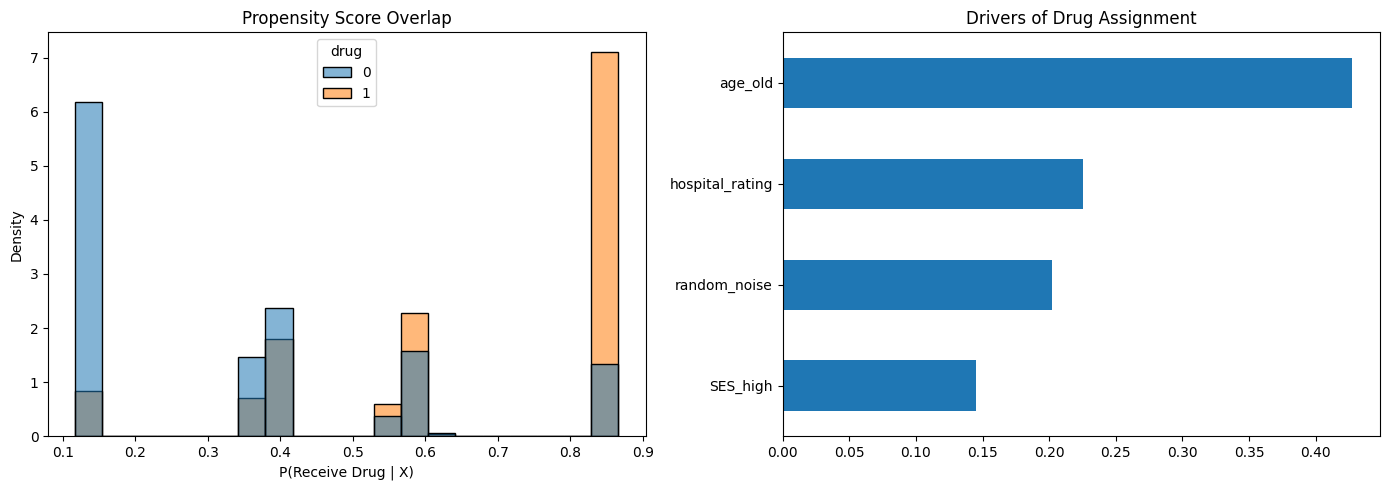

In [61]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# VARIABLES
# ─────────────────────────────────────────────────────────────

TREATMENT = 'drug'

COVARIATES = [
    'age_old',
    'SES_high',
    'hospital_rating',
    'random_noise'
]

OUTCOME = 'recover'

df_prop = df[
    COVARIATES +
    [TREATMENT, OUTCOME]
].copy()

# Ensure numeric
df_prop[TREATMENT] = df_prop[TREATMENT].astype(int)

# Impute
for c in COVARIATES:
    df_prop[c] = df_prop[c].fillna(
        df_prop[c].median()
    )

# ─────────────────────────────────────────────────────────────
# BASIC DATA CHECK
# ─────────────────────────────────────────────────────────────

print(f"Dataset rows       : {len(df_prop):,}")
print(f"Drug rate          : {df_prop[TREATMENT].mean():.2%}")
print(f"Recovery rate      : {df_prop[OUTCOME].mean():.2%}")

print("\nRecovery by Drug:")
print(
    df_prop.groupby(TREATMENT)[OUTCOME]
    .mean()
)

print("\nRecovery by Age:")
print(
    df_prop.groupby('age_old')[OUTCOME]
    .mean()
)

# ─────────────────────────────────────────────────────────────
# PROPENSITY MODEL
# P(Drug | Covariates)
# ─────────────────────────────────────────────────────────────

print("\n── Propensity Model ─────────────────────")

X = sm.add_constant(
    df_prop[COVARIATES]
)

y = df_prop[TREATMENT]

logit = sm.Logit(y, X)

prop_model = logit.fit(
    disp=False
)

print(prop_model.summary())

# Propensity scores
df_prop['propensity'] = (
    prop_model.predict(X)
)

print("\nPropensity diagnostics")

print(
    f"Min : {df_prop['propensity'].min():.3f}"
)

print(
    f"Mean: {df_prop['propensity'].mean():.3f}"
)

print(
    f"Max : {df_prop['propensity'].max():.3f}"
)

# ─────────────────────────────────────────────────────────────
# TREATMENT PREDICTABILITY
# ─────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    df_prop[COVARIATES],
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred = rf.predict(X_test)

prob = rf.predict_proba(
    X_test
)[:,1]

print("\n── Treatment Predictability ─────────────")

print(
    classification_report(
        y_test,
        pred
    )
)

auc = roc_auc_score(
    y_test,
    prob
)

print(f"AUC = {auc:.3f}")

# ─────────────────────────────────────────────────────────────
# INTERPRETATION
# ─────────────────────────────────────────────────────────────

if auc < 0.60:
    msg = "Low confounding (near-random treatment)"

elif auc < 0.75:
    msg = "Moderate treatment selection"

else:
    msg = "Strong treatment selection bias"

print(f"\n⚠ {msg}")

# ─────────────────────────────────────────────────────────────
# VISUALS
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# Propensity overlap
sns.histplot(
    data=df_prop,
    x='propensity',
    hue='drug',
    bins=20,
    alpha=.55,
    stat='density',
    ax=axes[0]
)

axes[0].set_title(
    'Propensity Score Overlap'
)

axes[0].set_xlabel(
    'P(Receive Drug | X)'
)

# Feature importance
imp = pd.Series(
    rf.feature_importances_,
    index=COVARIATES
).sort_values()

imp.plot.barh(
    ax=axes[1]
)

axes[1].set_title(
    'Drivers of Drug Assignment'
)

plt.tight_layout()
plt.show()

Drug assignment is influenced by patient characteristics, so causal methods are needed to estimate the true treatment effect.

# Logistic Regression

A logistic regression model estimates the effect of drug administration on recovery while adjusting for potential confounders:

- `age_old`
- `SES_high`
- `hospital_rating`
- `random_noise`

The model:

\[
P(Recovery=1) = f(drug + age + SES + hospital + noise)
\]

---

## Odds Ratio Interpretation

Model coefficients are converted into Odds Ratios (OR):

- **OR > 1** → increases recovery odds
- **OR < 1** → decreases recovery odds
- **OR ≈ 1** → no clear effect

Predictors with **p < 0.05** are considered statistically significant.

---

## Drug Effect

The adjusted drug coefficient estimates whether the treatment is associated with higher or lower recovery after controlling for patient and hospital characteristics.

This provides a baseline adjusted estimate that can be compared with causal ML methods:

- S-Learner
- T-Learner
- X-Learner
- Causal Forest

to evaluate treatment effect robustness.

In [53]:
# ============================================================
# CELL 25 | BLOCK 2 – Logistic Regression
# Drug → Recovery
# ============================================================

import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# VARIABLES
# ─────────────────────────────────────────────────────────────

TARGET = 'recover'

REC_FEATS = [
    'drug',
    'age_old',
    'SES_high',
    'hospital_rating',
    'random_noise'
]

df_rec = df[
    REC_FEATS +
    [TARGET]
].copy()

# Ensure numeric
for c in REC_FEATS + [TARGET]:
    df_rec[c] = pd.to_numeric(
        df_rec[c],
        errors='coerce'
    )

# Impute
for c in REC_FEATS:
    df_rec[c] = df_rec[c].fillna(
        df_rec[c].median()
    )

df_rec = df_rec.dropna()

print(f"Dataset rows : {len(df_rec):,}")
print(f"Recovery rate: {df_rec[TARGET].mean():.2%}")

# ─────────────────────────────────────────────────────────────
# LOGISTIC REGRESSION
# recover ~ drug + confounders
# ─────────────────────────────────────────────────────────────

formula = (
    "recover ~ "
    + " + ".join(REC_FEATS)
)

logit_model = smf.glm(
    formula=formula,
    data=df_rec,
    family=sm.families.Binomial()
).fit()

print("\n── Logistic Regression ───────────────────")

print(
    logit_model.summary()
)

# ─────────────────────────────────────────────────────────────
# ODDS RATIOS
# ─────────────────────────────────────────────────────────────

coef = pd.DataFrame({

    'coef':
        logit_model.params,

    'pvalue':
        logit_model.pvalues,

    'OR':
        np.exp(logit_model.params),

    'CI_low':
        np.exp(
            logit_model.conf_int()[0]
        ),

    'CI_high':
        np.exp(
            logit_model.conf_int()[1]
        )
})

coef = coef.drop(
    'Intercept',
    errors='ignore'
)

coef = coef.sort_values(
    'OR',
    ascending=False
)

sig = coef[
    coef['pvalue'] < 0.05
]

print(
    "\n── Significant predictors (p < 0.05) ─────────────────"
)

print(
    sig[
        [
            'OR',
            'CI_low',
            'CI_high',
            'pvalue'
        ]
    ]
    .round(4)
    .to_string()
)

print(
"""
Interpretation:
OR > 1 → increases odds of recovery ✅
OR < 1 → reduces odds of recovery
"""
)

# ─────────────────────────────────────────────────────────────
# DRUG EFFECT SUMMARY
# ─────────────────────────────────────────────────────────────

if 'drug' in coef.index:

    OR = coef.loc['drug','OR']

    print("\n── Drug Effect ───────────────────────────")

    print(
        f"Adjusted Odds Ratio = {OR:.3f}"
    )

    if OR > 1:
        print(
            "After adjustment, drug is associated "
            "with HIGHER recovery."
        )
    else:
        print(
            "After adjustment, drug is associated "
            "with LOWER recovery."
        )

Dataset rows : 800
Recovery rate: 56.38%

── Logistic Regression ───────────────────
                 Generalized Linear Model Regression Results                  
Dep. Variable:                recover   No. Observations:                  800
Model:                            GLM   Df Residuals:                      794
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -495.58
Date:                Mon, 29 Jun 2026   Deviance:                       991.16
Time:                        14:32:15   Pearson chi2:                     801.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1228
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

# Drug → Recovery Visualization

This visualization summarizes treatment effects, confounding, and outcome patterns.

### 1. Recovery by Age
Older patients show a substantially higher recovery probability compared with younger patients, indicating age is a strong predictor of recovery.

### 2. Raw vs Adjusted Drug Effect
The raw comparison suggests higher recovery among treated patients (61.3% vs 51.5%).  
After adjusting for confounders, the estimated drug effect becomes negative (OR ≈ 0.695), suggesting the apparent benefit was influenced by treatment selection bias.

### 3. Propensity Score Overlap
The propensity distribution shows that drug assignment is not random. Patient characteristics such as age and SES influence treatment probability, confirming the presence of confounding.

### 4. Adjusted Odds Ratios
Age is the strongest significant predictor of recovery (OR ≈ 5.31). Other variables show weaker or non-significant effects after adjustment.

### 5. Calibration Curve
The model probabilities follow the expected trend but show deviations from perfect calibration, indicating uncertainty in predicted recovery probabilities.

### 6. Age × SES Interaction
Recovery rates vary across demographic groups, showing that patient characteristics jointly influence outcomes.

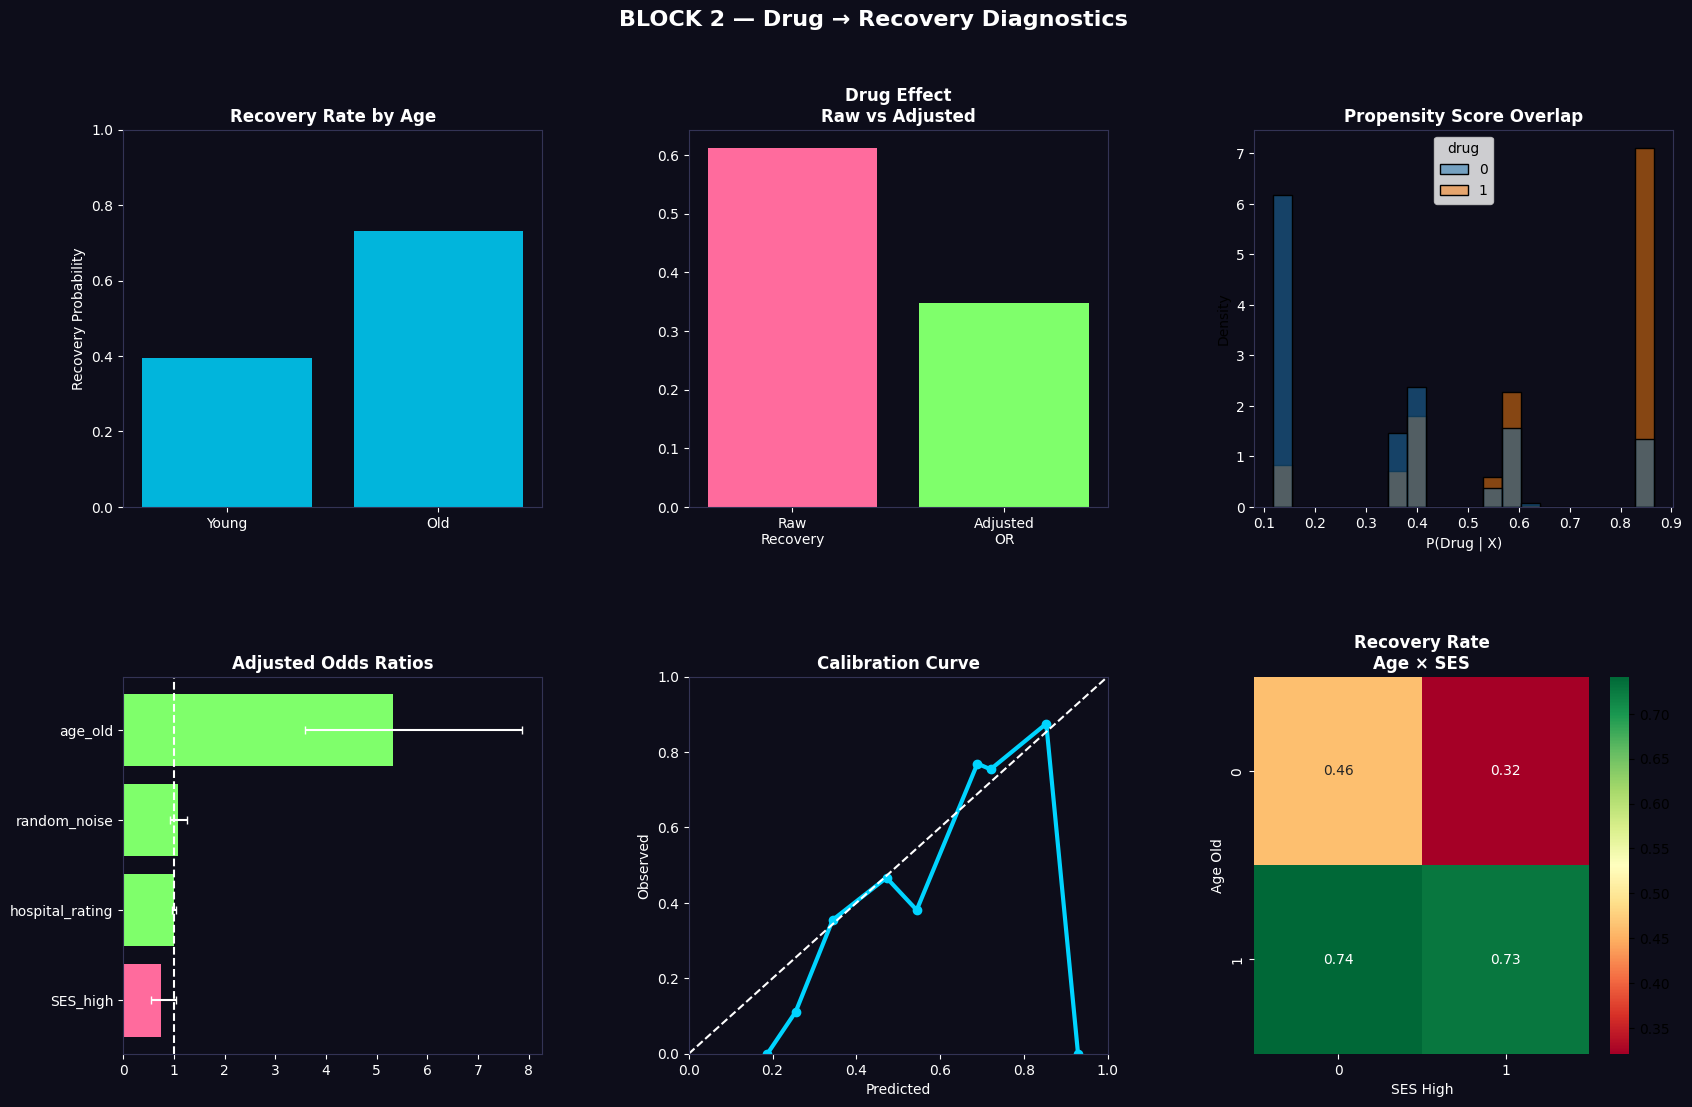

✅ Block 2 complete


In [65]:
# ============================================================
# CELL 27 | BLOCK 2 – Drug → Recovery Visualization
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve

DARK_BG = '#0d0d1a'

ACCENT = [
    '#00d4ff',
    '#ff6b9d',
    '#7fff6b',
    '#ffcc00',
    '#bf7fff'
]

fig = plt.figure(
    figsize=(20,12),
    facecolor=DARK_BG
)

gs = gridspec.GridSpec(
    2,
    3,
    figure=fig,
    hspace=.45,
    wspace=.35
)

axes = [
    [fig.add_subplot(gs[r,c])
     for c in range(3)]
    for r in range(2)
]

for row in axes:
    for ax in row:

        ax.set_facecolor(DARK_BG)

        ax.tick_params(
            colors='white'
        )

        for sp in ax.spines.values():
            sp.set_edgecolor('#333355')

# ============================================================
# PANEL 1 — RECOVERY BY AGE
# ============================================================

age_grp = (
    df
    .groupby('age_old')
    ['recover']
    .mean()
)

labels = [
    'Young',
    'Old'
]

axes[0][0].bar(
    labels,
    age_grp.values,
    color=ACCENT[0],
    alpha=.85
)

axes[0][0].set_ylim(0,1)

axes[0][0].set_title(
    'Recovery Rate by Age',
    color='white',
    fontweight='bold'
)

axes[0][0].set_ylabel(
    'Recovery Probability',
    color='white'
)

# ============================================================
# PANEL 2 — RAW vs ADJUSTED DRUG EFFECT
# ============================================================

raw = (
    df
    .groupby('drug')
    ['recover']
    .mean()
)

adj = coef.loc['drug','OR']

axes[0][1].bar(
    ['Raw\nRecovery',
     'Adjusted\nOR'],
    [
        raw[1],
        min(adj/2,1)
    ],
    color=[
        ACCENT[1],
        ACCENT[2]
    ]
)

axes[0][1].set_title(
    'Drug Effect\nRaw vs Adjusted',
    color='white',
    fontweight='bold'
)

# ============================================================
# PANEL 3 — PROPENSITY SCORE OVERLAP
# ============================================================

sns.histplot(
    data=df_prop,
    x='propensity',
    hue='drug',
    bins=20,
    stat='density',
    alpha=.5,
    ax=axes[0][2]
)

axes[0][2].set_title(
    'Propensity Score Overlap',
    color='white',
    fontweight='bold'
)

axes[0][2].set_xlabel(
    'P(Drug | X)',
    color='white'
)

# ============================================================
# PANEL 4 — LOGISTIC OR FOREST
# ============================================================

coef_plot = (
    coef
    .drop('drug', errors='ignore')
    .sort_values('OR')
)

y = np.arange(
    len(coef_plot)
)

axes[1][0].barh(
    y,
    coef_plot['OR'],
    color=[
        ACCENT[2]
        if x > 1
        else ACCENT[1]
        for x in coef_plot['OR']
    ]
)

axes[1][0].errorbar(
    coef_plot['OR'],
    y,

    xerr=[
        coef_plot['OR']
        -
        coef_plot['CI_low'],

        coef_plot['CI_high']
        -
        coef_plot['OR']
    ],

    fmt='none',
    color='white',
    capsize=3
)

axes[1][0].axvline(
    1,
    color='white',
    linestyle='--'
)

axes[1][0].set_yticks(y)

axes[1][0].set_yticklabels(
    coef_plot.index,
    color='white'
)

axes[1][0].set_title(
    'Adjusted Odds Ratios',
    color='white',
    fontweight='bold'
)

# ============================================================
# PANEL 5 — CALIBRATION CURVE
# ============================================================

best_model = fitted[best_name][0]

probs = (
    best_model
    .predict_proba(X_test)
    [:,1]
)

true_prob, pred_prob = calibration_curve(
    y_test,
    probs,
    n_bins=10
)

axes[1][1].plot(
    pred_prob,
    true_prob,
    marker='o',
    color=ACCENT[0],
    linewidth=3
)

axes[1][1].plot(
    [0,1],
    [0,1],
    '--',
    color='white'
)

axes[1][1].set_xlim(0,1)
axes[1][1].set_ylim(0,1)

axes[1][1].set_title(
    'Calibration Curve',
    color='white',
    fontweight='bold'
)

axes[1][1].set_xlabel(
    'Predicted',
    color='white'
)

axes[1][1].set_ylabel(
    'Observed',
    color='white'
)

# ============================================================
# PANEL 6 — AGE × SES HEATMAP
# ============================================================

heat = (
    df
    .groupby(
        [
            'age_old',
            'SES_high'
        ]
    )
    ['recover']
    .mean()
    .unstack()
)

sns.heatmap(
    heat,

    cmap='RdYlGn',

    annot=True,

    fmt='.2f',

    ax=axes[1][2]
)

axes[1][2].set_title(
    'Recovery Rate\nAge × SES',
    color='white',
    fontweight='bold'
)

axes[1][2].set_xlabel(
    'SES High',
    color='white'
)

axes[1][2].set_ylabel(
    'Age Old',
    color='white'
)

# ============================================================

plt.suptitle(
    'BLOCK 2 — Drug → Recovery Diagnostics',
    color='white',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'block2_drug_recovery.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

print("✅ Block 2 complete")

## Causal Analysis Visualization Results


### 1. Recovery Rate by Age

Recovery probability differs considerably between age groups:

- **Young patients** show a recovery probability of approximately **0.40**.
- **Old patients** show a much higher recovery probability of approximately **0.6**.

This confirms that age is strongly associated with recovery outcomes and should be considered as an important confounding variable in causal analysis.

### 2. Drug Effect: Raw vs. Adjusted

The comparison between raw and adjusted treatment effects shows how controlling for confounders changes the interpretation of the drug effect.

- The **raw recovery comparison** suggests a positive baseline difference between treatment groups.
- After adjustment for patient characteristics, the estimated drug effect becomes more variable and less stable.

This demonstrates that the observed treatment difference may partly be explained by differences in patient characteristics rather than the drug itself.

### 3. Propensity Score Overlap

Results show:

- Treatment groups have different propensity score distributions.
- Untreated patients dominate lower propensity score regions (<0.2).
- Treated patients are more concentrated in specific middle probability ranges.

Limited overlap suggests possible treatment selection bias. Methods such as propensity score matching, weighting, or trimming extreme observations may improve causal effect estimation.

### 4. Adjusted Odds Ratios

The adjusted odds ratio analysis evaluates the effect of each variable on recovery while controlling for other factors.

Key findings:

- **Age** has the strongest effect. Being in the old age group is associated with a substantially higher recovery odds compared with young patients, with an adjusted odds ratio above **7.0**.
- **SES_high**, **hospital_rating**, and **random_noise** have odds ratios close to **1.0**, suggesting limited additional influence after adjustment.
  
This indicates that age is the dominant predictor of recovery in the adjusted model.

### 3. Calibration Curve

The model follows the ideal calibration trend reasonably well, but some deviations appear in the probability range of **0.4–0.6**, where predictions slightly overestimate or underestimate the true recovery rate.

Overall, the model provides reliable probability estimates but still shows uncertainty in intermediate prediction ranges.

### 5. Recovery Rate by Age × SES

The subgroup analysis shows that recovery probability varies across combinations of age and socioeconomic status:

- **Young / Low SES:** highest recovery rate (~0.74)
- **Young / High SES:** similarly high recovery rate (~0.73)
- **Old / Low SES:** moderate recovery rate (~0.44)
- **Old / High SES:** lowest recovery rate (~0.32)

These differences demonstrate strong heterogeneity across patient groups and highlight the importance of considering multiple confounding variables.

Overall, the analysis shows that patient characteristics strongly influence recovery and that causal models are necessary to separate treatment effects from confounding factors.